# PROJECT CONTENTS

## 1. Project Overview
Introduction, purpose, technologies, and main features.

## 2. Project Objectives
Goals and objectives of the expense tracking and analytics system.

## 3. Project Modules
Description of the different functional modules.

## 4. Project Methodology
Complete workflow from expense input to analysis and reporting.

## 5. Project Implementation
Python implementation of the expense tracker and data-analysis functions.

## 6. Data Storage
CSV and Google Drive-based persistent storage.

## 7. Data Analysis
Pandas-based statistical, category-wise, and monthly analysis.

## 8. Data Quality
Validation of missing values, duplicates, amounts, and dates.

## 9. Data Visualization
Charts and graphical analysis using Matplotlib.

## 10. Smart Insights
Automatic identification of spending patterns and recommendations.

## 11. Dashboards
Spending dashboard and budget dashboard.

## 12. Report Export
Excel-based analysis report generation.

## 13. Testing
Testing of the application's functionality and data consistency.

## 14. Expected Outcomes
Expected benefits and results of the system.

## 15. Limitations
Current limitations of the implementation.

## 16. Future Scope
Possible improvements and advanced features.

## 17. Conclusion
Overall summary of the completed project.

In [ ]:
print("=" * 50)
print("SMART PERSONAL EXPENSE TRACKER")
print("SPENDING ANALYTICS SYSTEM")
print("=" * 50)

# List to store all expenses
expenses = []

print("Project initialized successfully!")

SMART PERSONAL EXPENSE TRACKER
SPENDING ANALYTICS SYSTEM
Project initialized successfully!


In [41]:
def add_expense():
    print("\n========== ADD EXPENSE ==========")

    # Get and validate amount
    while True:
        try:
            amount = float(input("Enter expense amount: ₹"))

            if amount <= 0:
                print("Amount must be greater than 0. Please try again.")
            else:
                break

        except ValueError:
            print("Invalid amount! Please enter a number.")

    # Get and validate category
    while True:
        category = input("Enter category: ").strip()

        if category == "":
            print("Category cannot be empty. Please try again.")
        else:
            break

    # Get date
    date = input("Enter date (YYYY-MM-DD): ").strip()

    # Get description
    description = input("Enter description: ").strip()

    # Create expense dictionary
    expense = {
        "amount": amount,
        "category": category,
        "date": date,
        "description": description
    }

    # Add expense to the list
    expenses.append(expense)

    # Automatically save to CSV
    save_expenses()

    print("Expense added successfully! ✅")

In [44]:
add_expense()


========== ADD EXPENSE ==========
Enter expense amount: ₹250
Enter category: food
Enter date (YYYY-MM-DD): 2026-09-10
Enter description: lunch
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅


In [ ]:
add_expense()
add_expense()
add_expense()
add_expense()
add_expense()


========== ADD EXPENSE ==========
Enter expense amount: ₹120
Enter category: Transport
Enter date (YYYY-MM-DD): 2026-09-09
Enter description: Bus
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅

========== ADD EXPENSE ==========
Enter expense amount: ₹850
Enter category: Shopping
Enter date (YYYY-MM-DD): 2026-09-08
Enter description: Clothes
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅

========== ADD EXPENSE ==========
Enter expense amount: ₹1500
Enter category: Bills
Enter date (YYYY-MM-DD): 2026-09-05
Enter description: Electricity bill
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅

========== ADD EXPENSE ==========
Enter expense amount: ₹200
Enter category: Food
Enter date (YYYY-MM-DD): 2026-09-07
Enter description: Breakfast
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅

========== ADD EXPENSE ==========
Enter expense amount: ₹500
Enter category: Entertainment
En

In [ ]:
add_expense()


========== ADD EXPENSE ==========
Enter expense amount: ₹300
Enter category: Food
Enter date (YYYY-MM-DD): 2026-09-04
Enter description: Dinner
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅


In [ ]:
def view_expenses():
    print("\n========== ALL EXPENSES ==========")

    if len(expenses) == 0:
        print("No expenses found.")
        return

    print("-" * 75)
    print(f"{'No.':<5}{'Date':<15}{'Category':<15}{'Amount':<15}{'Description'}")
    print("-" * 75)

    for i, expense in enumerate(expenses, start=1):
        print(
            f"{i:<5}"
            f"{expense['date']:<15}"
            f"{expense['category']:<15}"
            f"₹{expense['amount']:<14.2f}"
            f"{expense['description']}"
        )

    print("-" * 75)

In [ ]:
view_expenses()


========== ALL EXPENSES ==========
No expenses found.


In [ ]:
import csv

In [43]:
def save_expenses():
    filename = "expenses.csv"

    with open(filename, "w", newline="") as file:
        fieldnames = ["amount", "category", "date", "description"]

        writer = csv.DictWriter(file, fieldnames=fieldnames)

        writer.writeheader()
        writer.writerows(expenses)

    print("Expenses saved successfully to expenses.csv ✅")

In [ ]:
save_expenses()

Expenses saved successfully to expenses.csv ✅


In [ ]:
def load_expenses():
    filename = "expenses.csv"

    try:
        with open(filename, "r", newline="") as file:
            reader = csv.DictReader(file)

            expenses.clear()

            for row in reader:
                row["amount"] = float(row["amount"])
                expenses.append(row)

        print("Expenses loaded successfully from expenses.csv ✅")

    except FileNotFoundError:
        print("No previous expense file found. Starting with empty data.")

In [ ]:
load_expenses()

Expenses loaded successfully from expenses.csv ✅


In [ ]:
expenses.clear()

save_expenses()

print("All test expenses cleared. Starting with clean data! ✅")

Expenses saved successfully to expenses.csv ✅
All test expenses cleared. Starting with clean data! ✅


In [47]:
def search_expenses():
    print("\n========== SEARCH / FILTER EXPENSES ==========")

    if len(expenses) == 0:
        print("No expenses available to search.")
        return

    print("\n1. Search by Category")
    print("2. Search by Date")
    print("3. Search by Amount")
    print("4. Back")

    choice = input("\nEnter your choice (1-4): ").strip()

    if choice == "1":
        category = input("Enter category to search: ").strip().lower()

        found = False

        for expense in expenses:
            if expense["category"].lower() == category:
                print(
                    f"Date: {expense['date']} | "
                    f"Category: {expense['category']} | "
                    f"Amount: ₹{expense['amount']:.2f} | "
                    f"Description: {expense['description']}"
                )
                found = True

        if not found:
            print("No expenses found for this category.")

    elif choice == "2":
        date = input("Enter date (YYYY-MM-DD): ").strip()

        found = False

        for expense in expenses:
            if expense["date"] == date:
                print(
                    f"Date: {expense['date']} | "
                    f"Category: {expense['category']} | "
                    f"Amount: ₹{expense['amount']:.2f} | "
                    f"Description: {expense['description']}"
                )
                found = True

        if not found:
            print("No expenses found for this date.")

    elif choice == "3":
        try:
            minimum = float(input("Enter minimum amount: ₹"))
            maximum = float(input("Enter maximum amount: ₹"))

            found = False

            for expense in expenses:
                if minimum <= expense["amount"] <= maximum:
                    print(
                        f"Date: {expense['date']} | "
                        f"Category: {expense['category']} | "
                        f"Amount: ₹{expense['amount']:.2f} | "
                        f"Description: {expense['description']}"
                    )
                    found = True

            if not found:
                print("No expenses found in this amount range.")

        except ValueError:
            print("Invalid amount! Please enter numbers only.")

    elif choice == "4":
        print("Returning to main menu.")

    else:
        print("Invalid choice. Please select 1-4.")

In [ ]:
search_expenses()
search_expenses()
search_expenses()


========== SEARCH / FILTER EXPENSES ==========

1. Search by Category
2. Search by Date
3. Search by Amount
4. Back

Enter your choice (1-4): 1
Enter category to search: food
Date: 2026-09-10 | Category: Food | Amount: ₹300.00 | Description: Dinner

========== SEARCH / FILTER EXPENSES ==========

1. Search by Category
2. Search by Date
3. Search by Amount
4. Back

Enter your choice (1-4): 2
Enter date (YYYY-MM-DD): date
No expenses found for this date.

========== SEARCH / FILTER EXPENSES ==========

1. Search by Category
2. Search by Date
3. Search by Amount
4. Back

Enter your choice (1-4): 3
Enter minimum amount: ₹100 
Enter maximum amount: ₹500
Date: 2026-09-10 | Category: Food | Amount: ₹300.00 | Description: Dinner


In [54]:
def generate_report():
    print("\n========== EXPENSE REPORT ==========")

    if len(expenses) == 0:
        print("No expenses available for analysis.")
        return

    # Calculate total spending
    total = sum(expense["amount"] for expense in expenses)

    # Calculate number of expenses
    count = len(expenses)

    # Calculate average spending
    average = total / count

    # Find highest and lowest expenses
    highest = max(expenses, key=lambda x: x["amount"])
    lowest = min(expenses, key=lambda x: x["amount"])

    # Calculate category-wise spending
    category_totals = {}

    for expense in expenses:
        category = expense["category"]
        amount = expense["amount"]

        if category in category_totals:
            category_totals[category] += amount
        else:
            category_totals[category] = amount

    # Find highest spending category
    highest_category = max(
        category_totals,
        key=category_totals.get
    )

    print("-" * 50)
    print(f"Total Spending       : ₹{total:.2f}")
    print(f"Number of Expenses   : {count}")
    print(f"Average Expense      : ₹{average:.2f}")
    print(f"Highest Expense      : ₹{highest['amount']:.2f}")
    print(f"Highest Category     : {highest['category']}")
    print(f"Lowest Expense       : ₹{lowest['amount']:.2f}")
    print(f"Highest Spend Category: {highest_category}")
    print("-" * 50)

    print("\nCategory-wise Spending:")

    for category, amount in category_totals.items():
        percentage = (amount / total) * 100
        print(f"{category:<15} ₹{amount:>8.2f} ({percentage:.1f}%)")

In [ ]:
generate_report()


========== EXPENSE REPORT ==========
--------------------------------------------------
Total Spending       : ₹300.00
Number of Expenses   : 1
Average Expense      : ₹300.00
Highest Expense      : ₹300.00
Highest Category     : Food
Lowest Expense       : ₹300.00
Highest Spend Category: Food
--------------------------------------------------

Category-wise Spending:
Food            ₹  300.00 (100.0%)


In [55]:
def category_analysis():
    print("\n========== CATEGORY-WISE ANALYSIS ==========")

    if len(expenses) == 0:
        print("No expenses available for analysis.")
        return

    category_totals = {}

    # Calculate total for each category
    for expense in expenses:
        category = expense["category"]
        amount = expense["amount"]

        if category in category_totals:
            category_totals[category] += amount
        else:
            category_totals[category] = amount

    # Calculate overall total
    total = sum(category_totals.values())

    print("\nCategory        Amount          Percentage")
    print("-" * 50)

    for category, amount in category_totals.items():
        percentage = (amount / total) * 100

        print(
            f"{category:<15}"
            f"₹{amount:<14.2f}"
            f"{percentage:.1f}%"
        )

    # Find highest spending category
    highest_category = max(
        category_totals,
        key=category_totals.get
    )

    print("-" * 50)
    print(
        f"Highest Spending Category: "
        f"{highest_category} "
        f"(₹{category_totals[highest_category]:.2f})"
    )

In [ ]:
category_analysis()


========== CATEGORY-WISE ANALYSIS ==========

Category        Amount          Percentage
--------------------------------------------------
Food           ₹800.00        21.2%
Transport      ₹120.00        3.2%
Shopping       ₹850.00        22.5%
Bills          ₹1500.00       39.8%
Entertainment  ₹500.00        13.3%
--------------------------------------------------
Highest Spending Category: Bills (₹1500.00)


In [56]:
def monthly_analysis():
    print("\n========== MONTHLY SPENDING ANALYSIS ==========")

    if len(expenses) == 0:
        print("No expenses available for analysis.")
        return

    monthly_totals = {}

    # Calculate spending for each month
    for expense in expenses:
        date = expense["date"]
        amount = expense["amount"]

        # Extract year and month
        month = date[:7]

        if month in monthly_totals:
            monthly_totals[month] += amount
        else:
            monthly_totals[month] = amount

    print("\nMonth           Total Spending")
    print("-" * 40)

    for month, amount in sorted(monthly_totals.items()):
        print(f"{month:<15} ₹{amount:.2f}")

    # Find highest spending month
    highest_month = max(
        monthly_totals,
        key=monthly_totals.get
    )

    print("-" * 40)
    print(
        f"Highest Spending Month: "
        f"{highest_month} "
        f"(₹{monthly_totals[highest_month]:.2f})"
    )

In [ ]:
monthly_analysis()


========== MONTHLY SPENDING ANALYSIS ==========

Month           Total Spending
----------------------------------------
2026-09         ₹3770.00
----------------------------------------
Highest Spending Month: 2026-09 (₹3770.00)


In [57]:
def budget_analysis():
    print("\n========== BUDGET ANALYSIS ==========")

    if len(expenses) == 0:
        print("No expenses available.")
        return

    # Ask user for monthly budget
    while True:
        try:
            budget = float(input("Enter your monthly budget: ₹"))

            if budget <= 0:
                print("Budget must be greater than 0.")
            else:
                break

        except ValueError:
            print("Invalid budget! Please enter a number.")

    # Calculate total spending
    total_spent = sum(expense["amount"] for expense in expenses)

    # Calculate remaining budget
    remaining = budget - total_spent

    # Calculate percentage used
    percentage_used = (total_spent / budget) * 100

    print("\n------------------------------------------")
    print(f"Monthly Budget       : ₹{budget:.2f}")
    print(f"Total Spent          : ₹{total_spent:.2f}")

    if remaining >= 0:
        print(f"Remaining Budget     : ₹{remaining:.2f}")
    else:
        print(f"Budget Exceeded By   : ₹{abs(remaining):.2f}")

    print(f"Budget Used          : {percentage_used:.1f}%")
    print("------------------------------------------")

    # Determine budget status
    if percentage_used < 80:
        print("Status: 🟢 Within Budget")

    elif percentage_used < 100:
        print("Status: 🟡 Warning - Budget Almost Used")

    else:
        print("Status: 🔴 Budget Exceeded")

    print("------------------------------------------")

In [ ]:
budget_analysis()


========== BUDGET ANALYSIS ==========
Enter your monthly budget: ₹10000

------------------------------------------
Monthly Budget       : ₹10000.00
Total Spent          : ₹3770.00
Remaining Budget     : ₹6230.00
Budget Used          : 37.7%
------------------------------------------
Status: 🟢 Within Budget
------------------------------------------


In [58]:
import pandas as pd

In [ ]:
df = pd.read_csv("expenses.csv")

df

,amount,category,date,description
0,300.0,Food,2026-09-10,Dinner
1,120.0,Transport,2026-09-09,Bus
2,850.0,Shopping,2026-09-08,Clothes
3,1500.0,Bills,2026-09-05,Electricity bill
4,200.0,Food,2026-09-07,Breakfast
5,500.0,Entertainment,2026-09-06,Movie
6,300.0,Food,2026-09-04,Dinner


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   amount       7 non-null      float64
 1   category     7 non-null      object 
 2   date         7 non-null      object 
 3   description  7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 356.0+ bytes


In [ ]:
df["amount"].describe()

,amount
count,7.000000
mean,538.571429
std,487.593703
min,120.000000
25%,250.000000
50%,300.000000
75%,675.000000
max,1500.000000


In [ ]:
total_spending = df["amount"].sum()

print(f"Total Spending: ₹{total_spending:.2f}")

Total Spending: ₹3770.00


In [ ]:
average_spending = df["amount"].mean()

print(f"Average Expense: ₹{average_spending:.2f}")

Average Expense: ₹538.57


In [ ]:
highest_expense = df.loc[df["amount"].idxmax()]

print("========== HIGHEST EXPENSE ==========")
print(f"Amount      : ₹{highest_expense['amount']:.2f}")
print(f"Category    : {highest_expense['category']}")
print(f"Date        : {highest_expense['date']}")
print(f"Description : {highest_expense['description']}")

========== HIGHEST EXPENSE ==========
Amount      : ₹1500.00
Category    : Bills
Date        : 2026-09-05
Description : Electricity bill


In [ ]:
category_summary = (
    df.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("========== PANDAS CATEGORY ANALYSIS ==========")
print(category_summary)

========== PANDAS CATEGORY ANALYSIS ==========
category
Bills            1500.0
Shopping          850.0
Food              800.0
Entertainment     500.0
Transport         120.0
Name: amount, dtype: float64


In [ ]:
category_percentage = (
    category_summary / category_summary.sum() * 100
)

print("========== CATEGORY PERCENTAGE ==========")

for category, percentage in category_percentage.items():
    print(f"{category:<15} {percentage:.2f}%")

========== CATEGORY PERCENTAGE ==========
Bills           39.79%
Shopping        22.55%
Food            21.22%
Entertainment   13.26%
Transport       3.18%


In [ ]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Create a month column
df["month"] = df["date"].dt.to_period("M")

# Calculate monthly spending
monthly_summary = (
    df.groupby("month")["amount"]
    .sum()
    .sort_index()
)

print("========== PANDAS MONTHLY ANALYSIS ==========")
print(monthly_summary)

========== PANDAS MONTHLY ANALYSIS ==========
month
2026-09    3770.0
Freq: M, Name: amount, dtype: float64


In [ ]:
print("========== MONTHLY SPENDING ==========")

for month, amount in monthly_summary.items():
    print(f"{month} : ₹{amount:.2f}")

========== MONTHLY SPENDING ==========
2026-09 : ₹3770.00


In [ ]:
print("========== DATA QUALITY CHECK ==========")

print("\nMissing Values:")
print(df.isnull().sum())

========== DATA QUALITY CHECK ==========

Missing Values:
amount         0
category       0
date           0
description    0
month          0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 0


In [ ]:
invalid_amounts = df[df["amount"] <= 0]

print("========== INVALID AMOUNT CHECK ==========")

if len(invalid_amounts) == 0:
    print("No invalid amounts found. ✅")
else:
    print(invalid_amounts)

========== INVALID AMOUNT CHECK ==========
No invalid amounts found. ✅


In [ ]:
invalid_dates = df[df["date"].isnull()]

print("========== DATE VALIDATION ==========")

if len(invalid_dates) == 0:
    print("All dates are valid. ✅")
else:
    print(invalid_dates)

========== DATE VALIDATION ==========
All dates are valid. ✅


In [ ]:
clean_df = df.copy()

# Remove duplicate records
clean_df = clean_df.drop_duplicates()

# Remove records with missing important values
clean_df = clean_df.dropna(
    subset=["amount", "category", "date"]
)

# Keep only positive expenses
clean_df = clean_df[clean_df["amount"] > 0]

# Reset index
clean_df = clean_df.reset_index(drop=True)

print("========== CLEANED DATA ==========")
print(f"Original Records : {len(df)}")
print(f"Cleaned Records  : {len(clean_df)}")

========== CLEANED DATA ==========
Original Records : 7
Cleaned Records  : 7


In [ ]:
import matplotlib.pyplot as plt

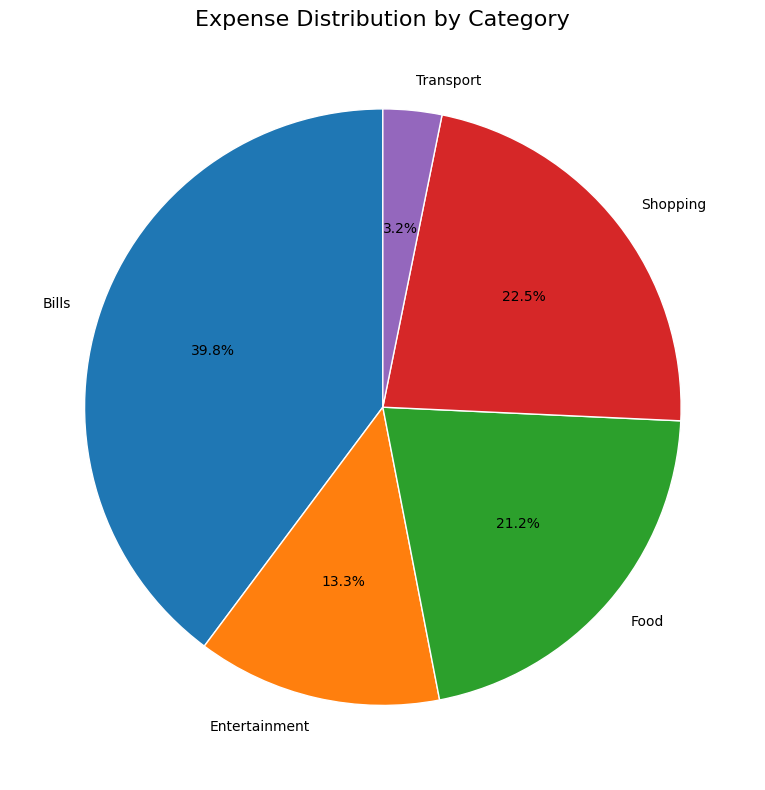

In [ ]:
# Category-wise spending data
category_data = clean_df.groupby("category")["amount"].sum()

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    category_data,
    labels=category_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

plt.title(
    "Expense Distribution by Category",
    fontsize=16
)

plt.tight_layout()
plt.show()

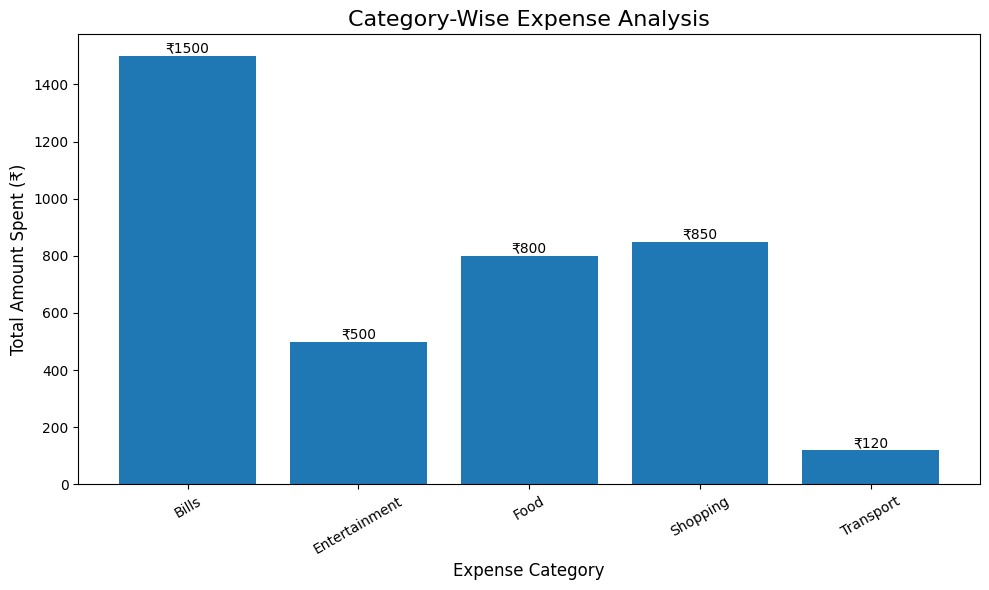

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_data.index,
    category_data.values
)

plt.title("Category-Wise Expense Analysis", fontsize=16)
plt.xlabel("Expense Category", fontsize=12)
plt.ylabel("Total Amount Spent (₹)", fontsize=12)

plt.xticks(rotation=30)

# Add amount labels above each bar
for bar in bars:
    amount = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        amount,
        f"₹{amount:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

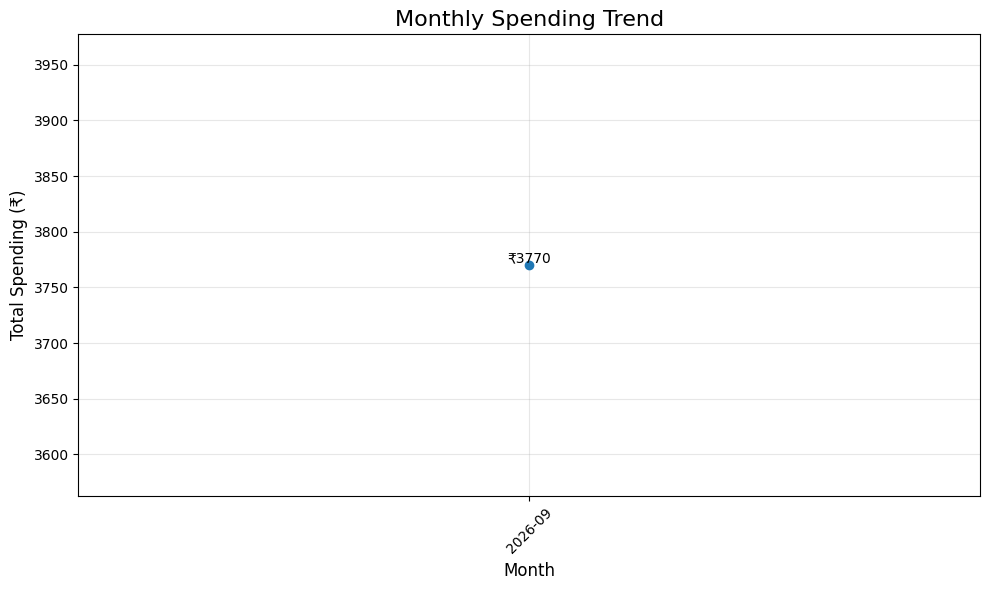

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Spending Trend",
    fontsize=16
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Spending (₹)", fontsize=12)

plt.xticks(rotation=45)

# Add values to points
for x, y in zip(
    monthly_summary.index.astype(str),
    monthly_summary.values
):
    plt.text(
        x,
        y,
        f"₹{y:.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import random
from datetime import datetime, timedelta

In [ ]:
# Generate synthetic expense data

categories = [
    "Food",
    "Transport",
    "Shopping",
    "Bills",
    "Entertainment",
    "Healthcare",
    "Education",
    "Travel"
]

descriptions = {
    "Food": [
        "Breakfast",
        "Lunch",
        "Dinner",
        "Restaurant",
        "Groceries"
    ],
    "Transport": [
        "Bus",
        "Auto",
        "Fuel",
        "Metro",
        "Cab"
    ],
    "Shopping": [
        "Clothes",
        "Shoes",
        "Accessories",
        "Online Shopping"
    ],
    "Bills": [
        "Electricity Bill",
        "Internet Bill",
        "Mobile Bill",
        "Water Bill",
        "Rent"
    ],
    "Entertainment": [
        "Movie",
        "Games",
        "Concert",
        "Streaming Subscription"
    ],
    "Healthcare": [
        "Medicine",
        "Doctor Visit",
        "Health Checkup"
    ],
    "Education": [
        "Books",
        "Course",
        "Stationery",
        "Online Learning"
    ],
    "Travel": [
        "Hotel",
        "Train Ticket",
        "Flight Ticket",
        "Trip"
    ]
}

# Start date
start_date = datetime(2026, 1, 1)

# Create 100 transactions
sample_expenses = []

for i in range(100):

    random_days = random.randint(0, 272)

    expense_date = start_date + timedelta(days=random_days)

    category = random.choice(categories)

    description = random.choice(descriptions[category])

    amount = random.randint(100, 5000)

    sample_expenses.append({
        "amount": amount,
        "category": category,
        "date": expense_date.strftime("%Y-%m-%d"),
        "description": description
    })

print(f"Generated {len(sample_expenses)} sample expenses successfully! ✅")

Generated 100 sample expenses successfully! ✅


In [ ]:
sample_df = pd.DataFrame(sample_expenses)

sample_df.head(10)

,amount,category,date,description
0,4142,Food,2026-02-03,Groceries
1,1486,Bills,2026-02-24,Internet Bill
2,644,Shopping,2026-08-02,Online Shopping
3,2361,Entertainment,2026-09-20,Streaming Subscription
4,1822,Shopping,2026-03-10,Accessories
5,487,Food,2026-04-28,Breakfast
6,1374,Transport,2026-04-08,Cab
7,1030,Education,2026-02-03,Course
8,2011,Healthcare,2026-09-27,Doctor Visit
9,3730,Shopping,2026-05-16,Shoes


In [ ]:
sample_df = sample_df.sort_values("date").reset_index(drop=True)

sample_df.head(10)

,amount,category,date,description
0,1407,Bills,2026-01-07,Mobile Bill
1,3922,Travel,2026-01-07,Train Ticket
2,1478,Food,2026-01-09,Dinner
3,838,Entertainment,2026-01-10,Games
4,1970,Entertainment,2026-01-12,Games
5,3577,Bills,2026-01-13,Electricity Bill
6,4834,Entertainment,2026-01-15,Movie
7,2560,Shopping,2026-01-15,Accessories
8,1084,Transport,2026-01-20,Fuel
9,2598,Food,2026-01-23,Dinner


In [ ]:
sample_df.to_csv(
    "expenses.csv",
    index=False
)

print("Synthetic expense dataset saved to expenses.csv ✅")

Synthetic expense dataset saved to expenses.csv ✅


In [ ]:
df = pd.read_csv("expenses.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,amount,category,date,description
0,1407,Bills,2026-01-07,Mobile Bill
1,3922,Travel,2026-01-07,Train Ticket
2,1478,Food,2026-01-09,Dinner
3,838,Entertainment,2026-01-10,Games
4,1970,Entertainment,2026-01-12,Games


In [ ]:
print(f"Number of transactions: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

Number of transactions: 100
Number of columns: 4


In [ ]:
print("========== DATASET OVERVIEW ==========")

print(f"Total Transactions : {len(df)}")
print(f"Total Spending     : ₹{df['amount'].sum():,.2f}")
print(f"Average Expense    : ₹{df['amount'].mean():,.2f}")
print(f"Minimum Expense    : ₹{df['amount'].min():,.2f}")
print(f"Maximum Expense    : ₹{df['amount'].max():,.2f}")

========== DATASET OVERVIEW ==========
Total Transactions : 100
Total Spending     : ₹255,996.00
Average Expense    : ₹2,559.96
Minimum Expense    : ₹167.00
Maximum Expense    : ₹4,885.00


In [ ]:
category_spending = (
    df.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("========== TOP SPENDING CATEGORIES ==========")
print(category_spending)

========== TOP SPENDING CATEGORIES ==========
category
Entertainment    41474
Shopping         37261
Food             37186
Healthcare       33105
Transport        30990
Bills            27596
Travel           26398
Education        21986
Name: amount, dtype: int64


In [ ]:
top_category = category_spending.idxmax()
top_category_amount = category_spending.max()

print(
    f"Highest Spending Category: "
    f"{top_category} (₹{top_category_amount:,.2f})"
)

Highest Spending Category: Entertainment (₹41,474.00)


In [ ]:
monthly_spending = (
    df.groupby(df["date"].dt.to_period("M"))["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("========== MONTHLY SPENDING ==========")
print(monthly_spending)

========== MONTHLY SPENDING ==========
date
2026-02    41786
2026-09    40678
2026-01    32783
2026-08    29789
2026-05    26944
2026-03    26106
2026-06    21318
2026-07    18849
2026-04    17743
Freq: M, Name: amount, dtype: int64


In [ ]:
top_month = monthly_spending.idxmax()
top_month_amount = monthly_spending.max()

print(
    f"Highest Spending Month: "
    f"{top_month} (₹{top_month_amount:,.2f})"
)

Highest Spending Month: 2026-02 (₹41,786.00)


In [ ]:
transaction_count = (
    df["category"]
    .value_counts()
)

print("========== TRANSACTIONS BY CATEGORY ==========")
print(transaction_count)

========== TRANSACTIONS BY CATEGORY ==========
category
Shopping         17
Entertainment    15
Transport        14
Food             14
Healthcare       12
Travel           10
Bills            10
Education         8
Name: count, dtype: int64


In [ ]:
print("========== KEY INSIGHTS ==========")

total_spending = df["amount"].sum()

top_category = category_spending.idxmax()
top_category_amount = category_spending.max()

top_month = monthly_spending.idxmax()
top_month_amount = monthly_spending.max()

average_expense = df["amount"].mean()

print(
    f"1. Total spending is ₹{total_spending:,.2f}."
)

print(
    f"2. {top_category} is the highest spending category "
    f"with ₹{top_category_amount:,.2f}."
)

print(
    f"3. {top_month} recorded the highest monthly spending "
    f"of ₹{top_month_amount:,.2f}."
)

print(
    f"4. The average transaction value is "
    f"₹{average_expense:,.2f}."
)

print(
    f"5. There are {len(df)} transactions in the dataset."
)

========== KEY INSIGHTS ==========
1. Total spending is ₹255,996.00.
2. Entertainment is the highest spending category with ₹41,474.00.
3. 2026-02 recorded the highest monthly spending of ₹41,786.00.
4. The average transaction value is ₹2,559.96.
5. There are 100 transactions in the dataset.


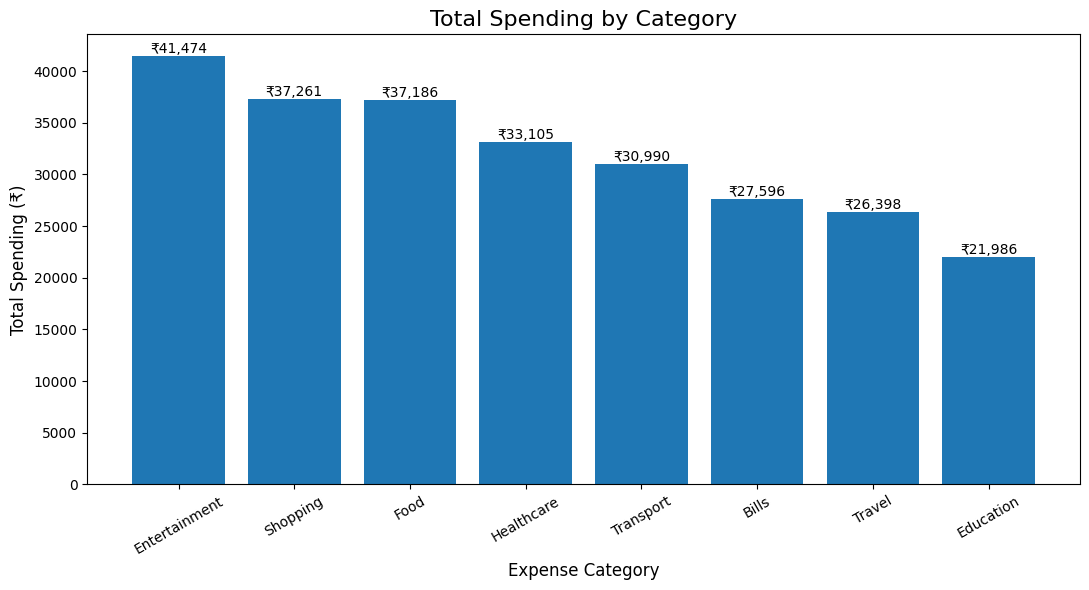

In [ ]:
category_spending = (
    df.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    category_spending.index,
    category_spending.values
)

plt.title(
    "Total Spending by Category",
    fontsize=16
)

plt.xlabel(
    "Expense Category",
    fontsize=12
)

plt.ylabel(
    "Total Spending (₹)",
    fontsize=12
)

plt.xticks(rotation=30)

# Add values above bars
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

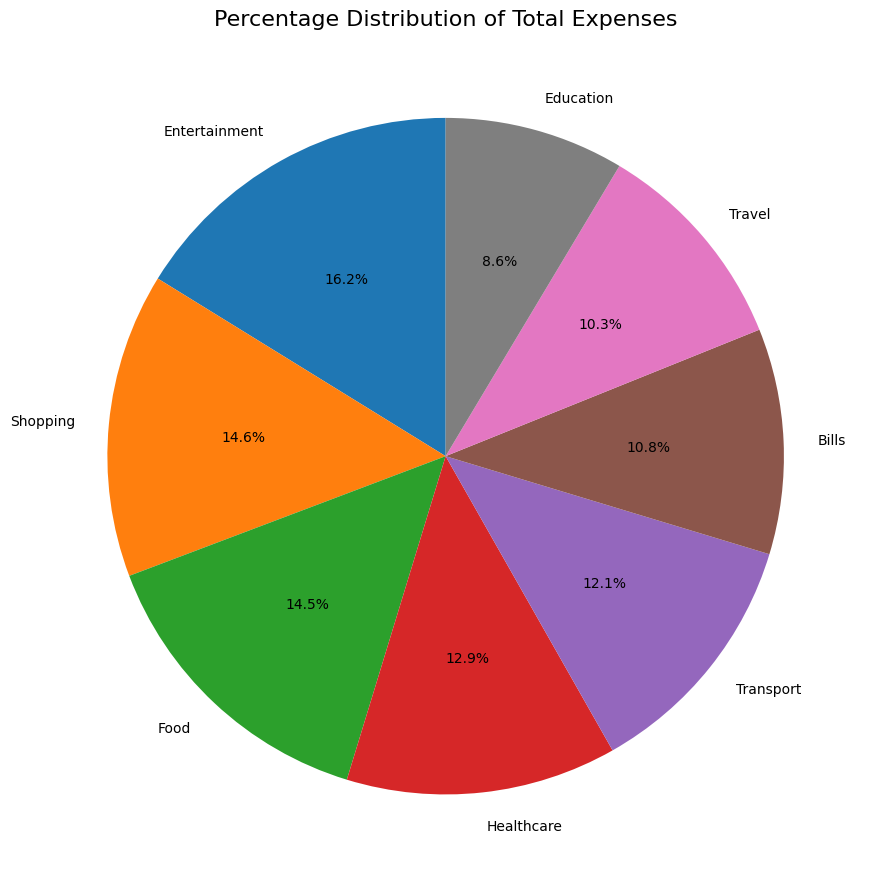

In [ ]:
plt.figure(figsize=(9, 9))

plt.pie(
    category_spending,
    labels=category_spending.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Percentage Distribution of Total Expenses",
    fontsize=16
)

plt.tight_layout()
plt.show()

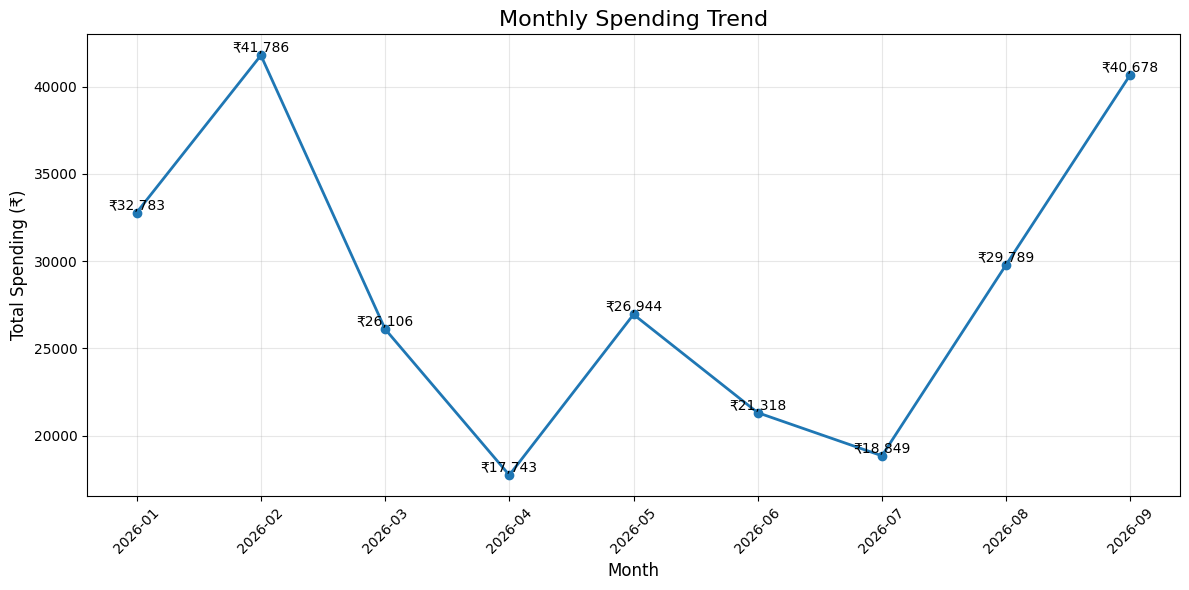

In [ ]:
monthly_spending = (
    df.groupby(df["date"].dt.to_period("M"))["amount"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_spending.index.astype(str),
    monthly_spending.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Spending Trend",
    fontsize=16
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Total Spending (₹)",
    fontsize=12
)

plt.xticks(rotation=45)

# Add values
for x, y in zip(
    monthly_spending.index.astype(str),
    monthly_spending.values
):
    plt.text(
        x,
        y,
        f"₹{y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

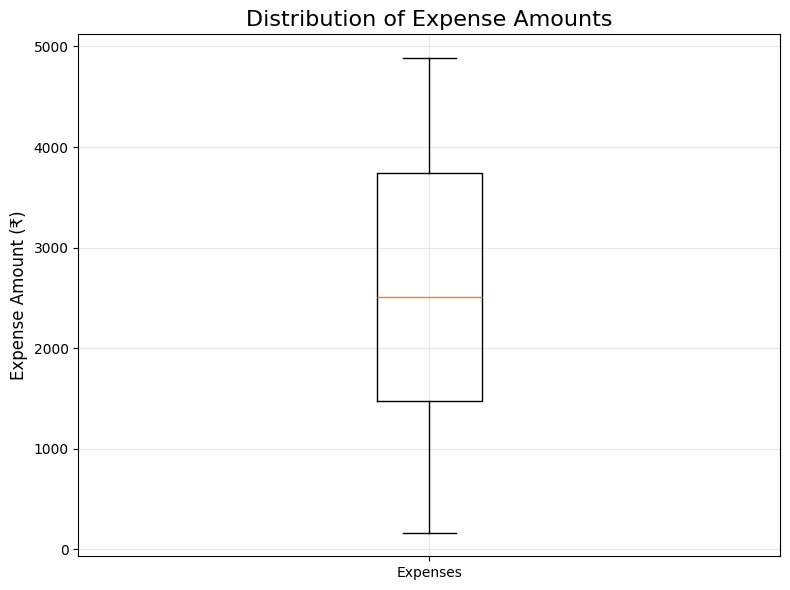

In [ ]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    df["amount"],
    vert=True
)

plt.title(
    "Distribution of Expense Amounts",
    fontsize=16
)

plt.ylabel(
    "Expense Amount (₹)",
    fontsize=12
)

plt.xticks(
    [1],
    ["Expenses"]
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["amount"] < lower_limit) |
    (df["amount"] > upper_limit)
]

print("========== OUTLIER ANALYSIS ==========")

print(f"Q1: ₹{Q1:,.2f}")
print(f"Q3: ₹{Q3:,.2f}")
print(f"IQR: ₹{IQR:,.2f}")

print(f"\nLower Limit: ₹{lower_limit:,.2f}")
print(f"Upper Limit: ₹{upper_limit:,.2f}")

print(f"\nNumber of Outliers: {len(outliers)}")

if len(outliers) > 0:
    print("\nPotential High/Low Expense Records:")
    display(outliers)
else:
    print("No significant outliers detected.")

========== OUTLIER ANALYSIS ==========
Q1: ₹1,472.75
Q3: ₹3,745.50
IQR: ₹2,272.75

Lower Limit: ₹-1,936.38
Upper Limit: ₹7,154.62

Number of Outliers: 0
No significant outliers detected.


In [59]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def create_dashboard():
    print("\n========== SMART EXPENSE DASHBOARD ==========")

    if len(df) == 0:
        print("No expense data available.")
        return

    # -----------------------------
    # KPI CALCULATIONS
    # -----------------------------
    total_spending = df["amount"].sum()
    average_expense = df["amount"].mean()
    highest_expense = df["amount"].max()
    transaction_count = len(df)

    # Category analysis
    category_summary = (
        df.groupby("category")["amount"]
        .sum()
        .sort_values(ascending=False)
    )

    top_category = category_summary.index[0]

    # Monthly analysis
    monthly_summary = (
        df.groupby("month")["amount"]
        .sum()
        .sort_index()
    )

    highest_month = monthly_summary.idxmax()

    # -----------------------------
    # CREATE DASHBOARD
    # -----------------------------
    fig = plt.figure(figsize=(16, 10))

    fig.suptitle(
        "SMART PERSONAL EXPENSE TRACKER",
        fontsize=22,
        fontweight="bold"
    )

    gs = GridSpec(
        3, 4,
        figure=fig,
        height_ratios=[1, 2, 2]
    )

    # -----------------------------
    # KPI 1
    # -----------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.axis("off")

    ax1.text(
        0.5, 0.6,
        f"₹{total_spending:,.0f}",
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

    ax1.text(
        0.5, 0.25,
        "TOTAL SPENDING",
        ha="center",
        fontsize=11
    )

    # -----------------------------
    # KPI 2
    # -----------------------------
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axis("off")

    ax2.text(
        0.5, 0.6,
        f"₹{average_expense:,.0f}",
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

    ax2.text(
        0.5, 0.25,
        "AVERAGE EXPENSE",
        ha="center",
        fontsize=11
    )

    # -----------------------------
    # KPI 3
    # -----------------------------
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis("off")

    ax3.text(
        0.5, 0.6,
        str(transaction_count),
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

    ax3.text(
        0.5, 0.25,
        "TRANSACTIONS",
        ha="center",
        fontsize=11
    )

    # -----------------------------
    # KPI 4
    # -----------------------------
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.axis("off")

    ax4.text(
        0.5, 0.6,
        f"₹{highest_expense:,.0f}",
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

    ax4.text(
        0.5, 0.25,
        "HIGHEST EXPENSE",
        ha="center",
        fontsize=11
    )

    # -----------------------------
    # CATEGORY CHART
    # -----------------------------
    ax5 = fig.add_subplot(gs[1:, :2])

    category_summary.plot(
        kind="bar",
        ax=ax5
    )

    ax5.set_title(
        "Spending by Category",
        fontsize=15,
        fontweight="bold"
    )

    ax5.set_xlabel("Category")
    ax5.set_ylabel("Amount (₹)")
    ax5.tick_params(axis="x", rotation=45)

    # -----------------------------
    # MONTHLY TREND
    # -----------------------------
    ax6 = fig.add_subplot(gs[1:, 2:])

    monthly_summary.plot(
        kind="line",
        marker="o",
        linewidth=2,
        ax=ax6
    )

    ax6.set_title(
        "Monthly Spending Trend",
        fontsize=15,
        fontweight="bold"
    )

    ax6.set_xlabel("Month")
    ax6.set_ylabel("Amount (₹)")
    ax6.tick_params(axis="x", rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()

    # -----------------------------
    # KEY INSIGHTS
    # -----------------------------
    print("\n========== KEY DASHBOARD INSIGHTS ==========")

    print(f"💰 Total Spending       : ₹{total_spending:,.2f}")
    print(f"📊 Average Expense      : ₹{average_expense:,.2f}")
    print(f"🧾 Total Transactions   : {transaction_count}")
    print(f"💸 Highest Expense      : ₹{highest_expense:,.2f}")
    print(f"🏆 Top Category         : {top_category}")
    print(f"📅 Highest Spending Month: {highest_month}")

    print("\nDashboard generated successfully! ✅")

In [ ]:
# Create month column for dashboard analysis

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

print("Month column created successfully! ✅")

Month column created successfully! ✅



========== SMART EXPENSE DASHBOARD ==========


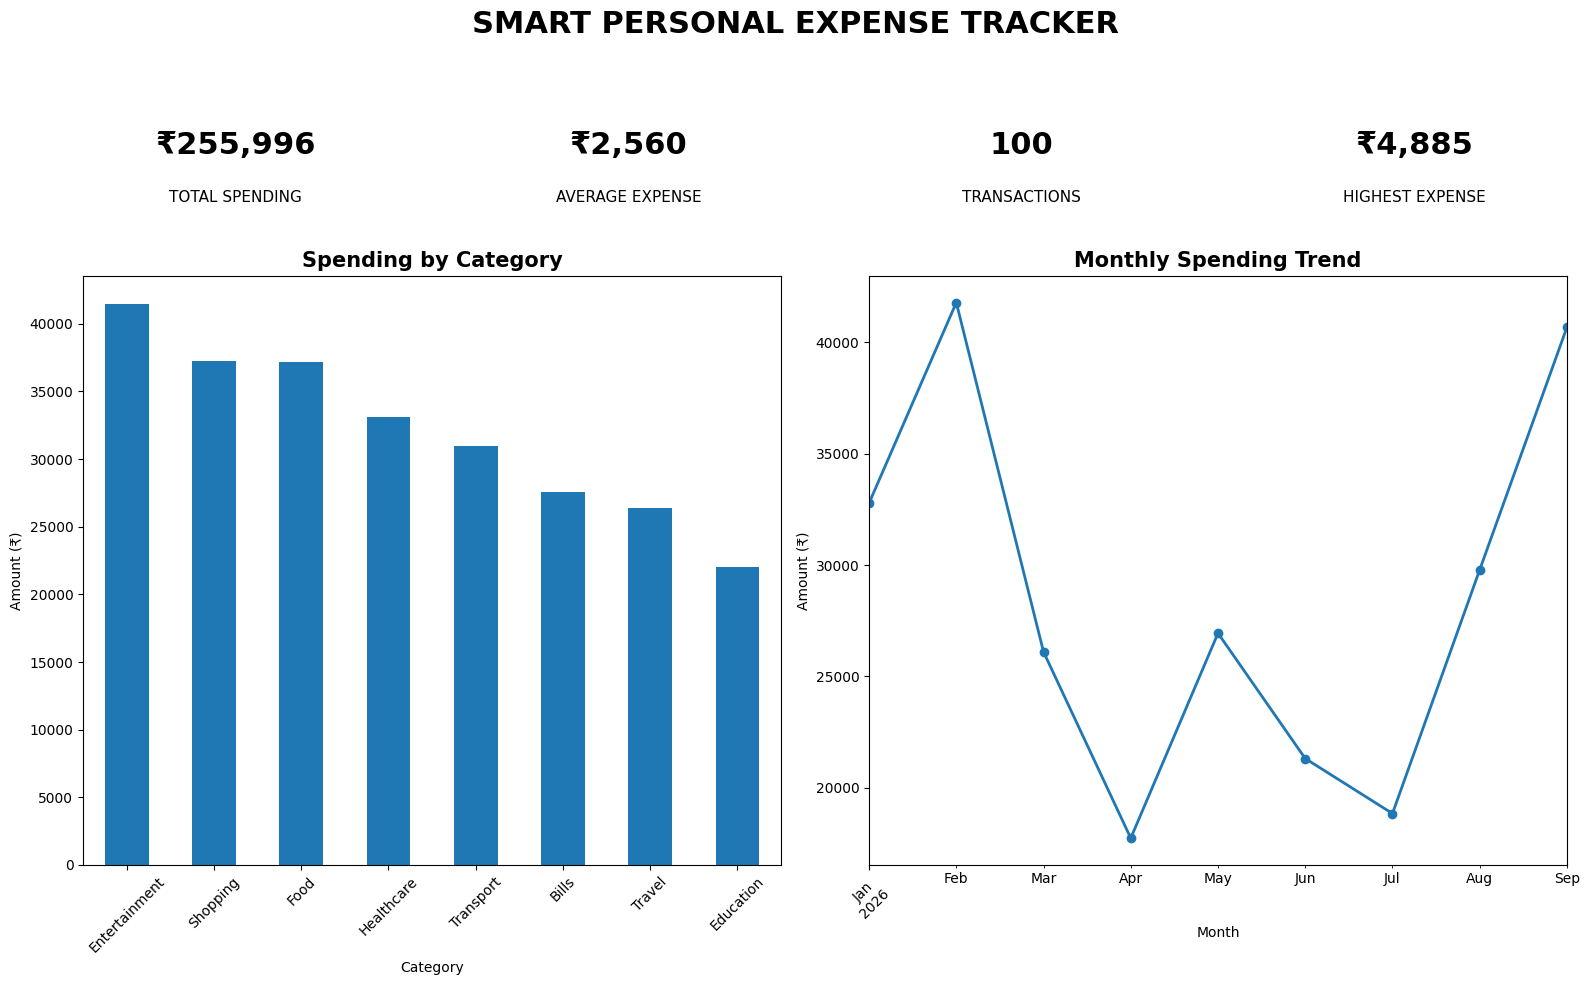


========== KEY DASHBOARD INSIGHTS ==========
💰 Total Spending       : ₹255,996.00
📊 Average Expense      : ₹2,559.96
🧾 Total Transactions   : 100
💸 Highest Expense      : ₹4,885.00
🏆 Top Category         : Entertainment
📅 Highest Spending Month: 2026-02

Dashboard generated successfully! ✅


In [ ]:
create_dashboard()

In [60]:
def smart_insights():

    print("\n========== SMART SPENDING INSIGHTS ==========")

    if len(df) == 0:
        print("No expense data available.")
        return

    # Total and average
    total_spending = df["amount"].sum()
    average_expense = df["amount"].mean()

    # Category analysis
    category_summary = (
        df.groupby("category")["amount"]
        .sum()
        .sort_values(ascending=False)
    )

    top_category = category_summary.index[0]
    top_category_amount = category_summary.iloc[0]

    category_percentage = (
        top_category_amount / total_spending
    ) * 100

    # Monthly analysis
    monthly_summary = (
        df.groupby("month")["amount"]
        .sum()
        .sort_index()
    )

    highest_month = monthly_summary.idxmax()
    highest_month_amount = monthly_summary.max()

    print(f"\n💰 Total Spending: ₹{total_spending:,.2f}")
    print(f"📊 Average Expense: ₹{average_expense:,.2f}")

    print(
        f"\n🏆 Highest Spending Category: "
        f"{top_category}"
    )

    print(
        f"   Amount Spent: ₹{top_category_amount:,.2f}"
    )

    print(
        f"   Percentage of Total Spending: "
        f"{category_percentage:.1f}%"
    )

    print(
        f"\n📅 Highest Spending Month: "
        f"{highest_month}"
    )

    print(
        f"   Amount Spent: ₹{highest_month_amount:,.2f}"
    )

    # -----------------------------
    # SMART RECOMMENDATIONS
    # -----------------------------

    print("\n========== RECOMMENDATIONS ==========")

    if category_percentage > 25:
        print(
            f"⚠️ {top_category} accounts for more than "
            f"25% of your total spending."
        )
        print(
            "💡 Consider reducing unnecessary expenses "
            "in this category."
        )
    else:
        print(
            "✅ Your spending is reasonably distributed "
            "across categories."
        )

    if average_expense > 3000:
        print(
            "⚠️ Your average transaction amount is relatively high."
        )
        print(
            "💡 Consider reviewing high-value purchases."
        )
    else:
        print(
            "✅ Your average transaction amount is under ₹3,000."
        )

    # Compare first and last month
    if len(monthly_summary) >= 2:

        first_month = monthly_summary.iloc[0]
        last_month = monthly_summary.iloc[-1]

        if last_month > first_month:
            increase = ((last_month - first_month) / first_month) * 100

            print(
                f"📈 Spending increased by "
                f"{increase:.1f}% from the first "
                f"to the latest month."
            )

        elif last_month < first_month:
            decrease = ((first_month - last_month) / first_month) * 100

            print(
                f"📉 Spending decreased by "
                f"{decrease:.1f}% from the first "
                f"to the latest month."
            )

        else:
            print(
                "➡️ Spending remained approximately "
                "the same."
            )

    print("\nSmart analysis completed successfully! ✅")

In [ ]:
smart_insights()


========== SMART SPENDING INSIGHTS ==========

💰 Total Spending: ₹255,996.00
📊 Average Expense: ₹2,559.96

🏆 Highest Spending Category: Entertainment
   Amount Spent: ₹41,474.00
   Percentage of Total Spending: 16.2%

📅 Highest Spending Month: 2026-02
   Amount Spent: ₹41,786.00

========== RECOMMENDATIONS ==========
✅ Your spending is reasonably distributed across categories.
✅ Your average transaction amount is under ₹3,000.
📈 Spending increased by 24.1% from the first to the latest month.

Smart analysis completed successfully! ✅


In [53]:
def monthly_budget_analysis():

    print("\n========== MONTHLY BUDGET TRACKER ==========")

    if len(df) == 0:
        print("No expense data available.")
        return

    # Show available months
    available_months = sorted(df["month"].astype(str).unique())

    print("\nAvailable Months:")
    for month in available_months:
        print("-", month)

    # Select month
    selected_month = input(
        "\nEnter month (YYYY-MM): "
    ).strip()

    if selected_month not in available_months:
        print("Invalid month. Please select from the available months.")
        return

    # Get budget
    while True:
        try:
            budget = float(
                input("Enter monthly budget: ₹")
            )

            if budget <= 0:
                print("Budget must be greater than 0.")
            else:
                break

        except ValueError:
            print("Invalid budget! Please enter a number.")

    # Calculate monthly spending
    month_data = df[
        df["month"].astype(str) == selected_month
    ]

    total_spent = month_data["amount"].sum()

    remaining = budget - total_spent

    percentage_used = (
        total_spent / budget
    ) * 100

    # Display results
    print("\n------------------------------------------")
    print(f"Month                : {selected_month}")
    print(f"Monthly Budget       : ₹{budget:,.2f}")
    print(f"Total Spent          : ₹{total_spent:,.2f}")

    if remaining >= 0:
        print(f"Remaining Budget     : ₹{remaining:,.2f}")
    else:
        print(
            f"Budget Exceeded By   : ₹{abs(remaining):,.2f}"
        )

    print(f"Budget Used          : {percentage_used:.1f}%")
    print("------------------------------------------")

    # Status
    if percentage_used < 80:
        print("Status: 🟢 Within Budget")

    elif percentage_used < 100:
        print("Status: 🟡 Warning - Budget Almost Used")

    else:
        print("Status: 🔴 Budget Exceeded")

    print("------------------------------------------")

    # Recommendation
    if percentage_used >= 100:
        print(
            "💡 Recommendation: Reduce unnecessary "
            "expenses for this month."
        )

    elif percentage_used >= 80:
        print(
            "💡 Recommendation: Monitor your spending "
            "carefully for the rest of the month."
        )

    else:
        print(
            "✅ Good job! You are comfortably within "
            "your monthly budget."
        )

In [ ]:
monthly_budget_analysis()


========== MONTHLY BUDGET TRACKER ==========

Available Months:
- 2026-01
- 2026-02
- 2026-03
- 2026-04
- 2026-05
- 2026-06
- 2026-07
- 2026-08
- 2026-09

Enter month (YYYY-MM): 2026-05
Enter monthly budget: ₹30000

------------------------------------------
Month                : 2026-05
Monthly Budget       : ₹30,000.00
Total Spent          : ₹26,944.00
Remaining Budget     : ₹3,056.00
Budget Used          : 89.8%
------------------------------------------
Status: 🟡 Warning - Budget Almost Used
------------------------------------------
💡 Recommendation: Monitor your spending carefully for the rest of the month.


In [ ]:
def main_menu():

    while True:

        print("\n")
        print("=" * 55)
        print("       SMART PERSONAL EXPENSE TRACKER")
        print("=" * 55)

        print("\n1. Add Expense")
        print("2. View Expenses")
        print("3. Search / Filter Expenses")
        print("4. Expense Report")
        print("5. Category Analysis")
        print("6. Monthly Analysis")
        print("7. Budget Analysis")
        print("8. Smart Insights")
        print("9. Dashboard")
        print("10. Exit")

        print("-" * 55)

        choice = input("Enter your choice (1-10): ").strip()

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            search_expenses()

        elif choice == "4":
            generate_report()

        elif choice == "5":
            category_analysis()

        elif choice == "6":
            monthly_analysis()

        elif choice == "7":
            monthly_budget_analysis()

        elif choice == "8":
            smart_insights()

        elif choice == "9":
            create_dashboard()

            print("\n" + "=" * 55)
            print("Dashboard displayed successfully! ✅")
            print("=" * 55)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "10":
            print("\n" + "=" * 55)
            print("Thank you for using Smart Personal Expense Tracker! 👋")
            print("Project closed successfully.")
            print("=" * 55)

            return

        else:
            print("\n❌ Invalid choice!")
            print("Please enter a number between 1 and 10.")



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Search / Filter Expenses
4. Expense Report
5. Category Analysis
6. Monthly Analysis
7. Budget Analysis
8. Smart Insights
9. Dashboard
10. Exit
-------------------------------------------------------
Enter your choice (1-10): 2

========== ALL EXPENSES ==========
---------------------------------------------------------------------------
No.  Date           Category       Amount         Description
---------------------------------------------------------------------------
1    2026-09-10     Food           ₹300.00        Dinner
2    2026-09-09     Transport      ₹120.00        Bus
3    2026-09-08     Shopping       ₹850.00        Clothes
4    2026-09-05     Bills          ₹1500.00       Electricity bill
5    2026-09-07     Food           ₹200.00        Breakfast
6    2026-09-06     Entertainment  ₹500.00        Movie
7    2026-09-04     Food           ₹300.00        Dinner
--------------------------------------

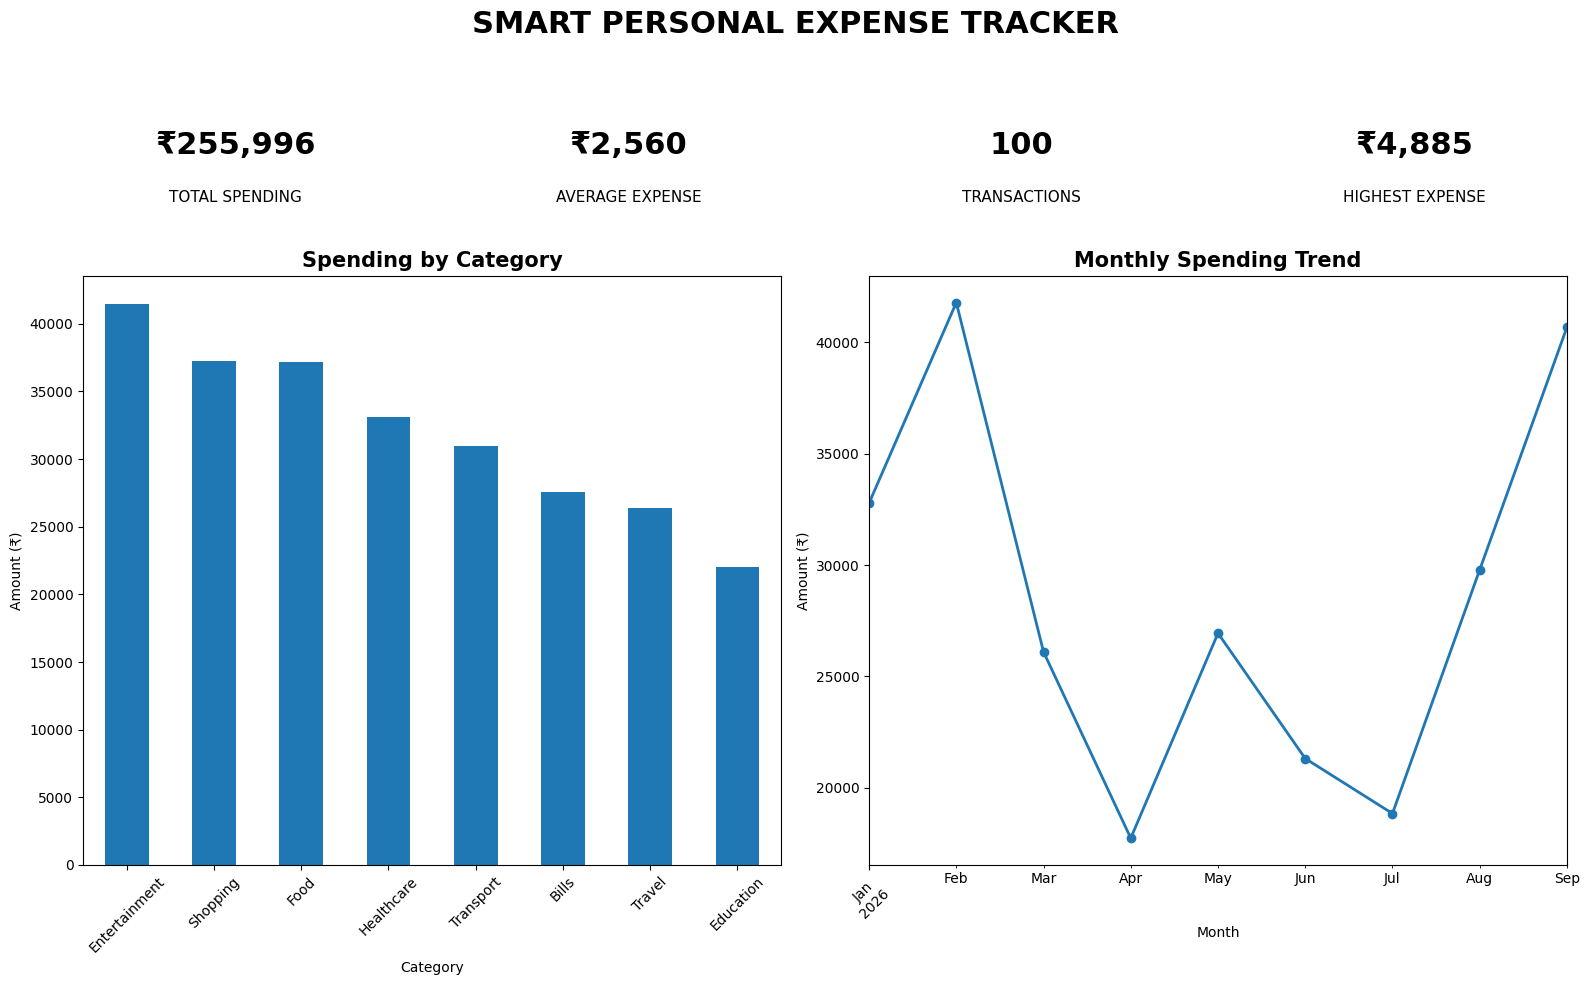


========== KEY DASHBOARD INSIGHTS ==========
💰 Total Spending       : ₹255,996.00
📊 Average Expense      : ₹2,559.96
🧾 Total Transactions   : 100
💸 Highest Expense      : ₹4,885.00
🏆 Top Category         : Entertainment
📅 Highest Spending Month: 2026-02

Dashboard generated successfully! ✅

Dashboard displayed successfully! ✅

To continue, run main_menu() again in a NEW cell.


In [ ]:
main_menu()

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [52]:
import os
import shutil

# Create project folder in Google Drive
project_folder = "/content/drive/MyDrive/Smart_Personal_Expense_Tracker"

os.makedirs(project_folder, exist_ok=True)

# Location of permanent CSV file
drive_csv = os.path.join(project_folder, "expenses.csv")

# Save current project data to Google Drive
save_expenses_to_drive = drive_csv

with open(drive_csv, "w", newline="") as file:
    fieldnames = ["amount", "category", "date", "description"]

    writer = csv.DictWriter(file, fieldnames=fieldnames)

    writer.writeheader()
    writer.writerows(expenses)

print("Project folder created successfully! ✅")
print("Expense data saved permanently to Google Drive! ☁️")
print(f"File location: {drive_csv}")

Project folder created successfully! ✅
Expense data saved permanently to Google Drive! ☁️
File location: /content/drive/MyDrive/Smart_Personal_Expense_Tracker/expenses.csv


In [51]:
# Permanent Google Drive file location

PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Personal_Expense_Tracker"
CSV_FILE = os.path.join(PROJECT_FOLDER, "expenses.csv")


def save_expenses():

    os.makedirs(PROJECT_FOLDER, exist_ok=True)

    with open(CSV_FILE, "w", newline="") as file:

        fieldnames = [
            "amount",
            "category",
            "date",
            "description"
        ]

        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames
        )

        writer.writeheader()
        writer.writerows(expenses)

    print("Expenses saved to Google Drive successfully! ☁️")


def load_expenses():

    try:

        with open(CSV_FILE, "r", newline="") as file:

            reader = csv.DictReader(file)

            expenses.clear()

            for row in reader:

                row["amount"] = float(row["amount"])

                expenses.append(row)

        print("Expenses loaded from Google Drive successfully! ☁️")
        print(f"Total expenses loaded: {len(expenses)}")

    except FileNotFoundError:

        print("No previous expense file found.")
        print("Starting with empty expense data.")

In [ ]:
load_expenses()

Expenses loaded from Google Drive successfully! ☁️
Total expenses loaded: 7


In [ ]:
print("Transactions currently in DataFrame:", len(df))
print("\nFirst 5 transactions:")
display(df.head())

Transactions currently in DataFrame: 100

First 5 transactions:


,amount,category,date,description,month
0,1407,Bills,2026-01-07,Mobile Bill,2026-01
1,3922,Travel,2026-01-07,Train Ticket,2026-01
2,1478,Food,2026-01-09,Dinner,2026-01
3,838,Entertainment,2026-01-10,Games,2026-01
4,1970,Entertainment,2026-01-12,Games,2026-01


In [ ]:
# Restore the 100 DataFrame records into the expenses list

expenses.clear()

for _, row in df.iterrows():
    expenses.append({
        "amount": float(row["amount"]),
        "category": row["category"],
        "date": row["date"].strftime("%Y-%m-%d"),
        "description": row["description"]
    })

print("Expenses list restored successfully! ✅")
print("Total expenses:", len(expenses))

Expenses list restored successfully! ✅
Total expenses: 100


In [ ]:
save_expenses()

Expenses saved to Google Drive successfully! ☁️


In [ ]:
load_expenses()

Expenses loaded from Google Drive successfully! ☁️
Total expenses loaded: 100


In [ ]:
# Automatically load saved expenses when the project starts

load_expenses()

print("\nSmart Personal Expense Tracker is ready! 🚀")
print(f"Current records available: {len(expenses)}")

Expenses loaded from Google Drive successfully! ☁️
Total expenses loaded: 100

Smart Personal Expense Tracker is ready! 🚀
Current records available: 100


In [21]:
def refresh_dataframe():

    global df

    df = pd.DataFrame(expenses)

    if len(df) == 0:
        print("No expense data available.")
        return

    df["amount"] = pd.to_numeric(
        df["amount"],
        errors="coerce"
    )

    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    df["month"] = df["date"].dt.to_period("M")

    print("DataFrame synchronized successfully! ✅")
    print(f"Total records: {len(df)}")

In [22]:
refresh_dataframe()

DataFrame synchronized successfully! ✅
Total records: 101


In [50]:
def add_expense():

    print("\n========== ADD EXPENSE ==========")

    # -----------------------------
    # AMOUNT VALIDATION
    # -----------------------------
    while True:
        try:
            amount = float(
                input("Enter expense amount: ₹")
            )

            if amount <= 0:
                print(
                    "Amount must be greater than 0. "
                    "Please try again."
                )
            else:
                break

        except ValueError:
            print(
                "Invalid amount! "
                "Please enter a number."
            )

    # -----------------------------
    # CATEGORY VALIDATION
    # -----------------------------
    while True:

        category = input(
            "Enter category: "
        ).strip()

        if category == "":
            print(
                "Category cannot be empty. "
                "Please try again."
            )
        else:
            # Convert to proper format
            category = category.title()
            break

    # -----------------------------
    # DATE VALIDATION
    # -----------------------------
    while True:

        date = input(
            "Enter date (YYYY-MM-DD): "
        ).strip()

        try:
            valid_date = pd.to_datetime(
                date,
                format="%Y-%m-%d"
            )

            date = valid_date.strftime(
                "%Y-%m-%d"
            )

            break

        except ValueError:
            print(
                "Invalid date! "
                "Please use YYYY-MM-DD."
            )

    # -----------------------------
    # DESCRIPTION
    # -----------------------------
    description = input(
        "Enter description: "
    ).strip()

    if description == "":
        description = "No description"

    # -----------------------------
    # CREATE EXPENSE
    # -----------------------------
    expense = {
        "amount": amount,
        "category": category,
        "date": date,
        "description": description
    }

    # Add to list
    expenses.append(expense)

    # Save permanently
    save_expenses()

    # Update Pandas DataFrame
    refresh_dataframe()

    print("\nExpense added successfully! ✅")
    print(f"Amount   : ₹{amount:,.2f}")
    print(f"Category : {category}")
    print(f"Date     : {date}")

In [ ]:
main_menu()



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Search / Filter Expenses
4. Expense Report
5. Category Analysis
6. Monthly Analysis
7. Budget Analysis
8. Smart Insights
9. Dashboard
10. Exit
-------------------------------------------------------
Enter your choice (1-10): 1

========== ADD EXPENSE ==========
Enter expense amount: ₹150
Enter category: food
Enter date (YYYY-MM-DD): 2026-09-10
Enter description: coffee
Expenses saved to Google Drive successfully! ☁️
DataFrame synchronized successfully! ✅
Total records: 101

Expense added successfully! ✅
Amount   : ₹150.00
Category : Food
Date     : 2026-09-10


       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Search / Filter Expenses
4. Expense Report
5. Category Analysis
6. Monthly Analysis
7. Budget Analysis
8. Smart Insights
9. Dashboard
10. Exit
-------------------------------------------------------
Enter your choice (1-10): 2

========== ALL EXPENSES ==========
-------------------

In [1]:
def delete_expense():

    print("\n========== DELETE EXPENSE ==========")

    if len(expenses) == 0:
        print("No expenses available to delete.")
        return

    # Display expenses
    print("\nAvailable Expenses:")
    print("-" * 75)

    for i, expense in enumerate(expenses, start=1):
        print(
            f"{i}. "
            f"{expense['date']} | "
            f"{expense['category']} | "
            f"₹{expense['amount']:.2f} | "
            f"{expense['description']}"
        )

    print("-" * 75)

    # Select expense
    while True:
        try:
            number = int(
                input(
                    f"Enter expense number to delete "
                    f"(1-{len(expenses)}): "
                )
            )

            if 1 <= number <= len(expenses):
                break

            print(
                f"Please enter a number between "
                f"1 and {len(expenses)}."
            )

        except ValueError:
            print("Invalid input! Please enter a number.")

    # Get selected expense
    selected = expenses[number - 1]

    print("\nSelected Expense:")
    print(
        f"Date        : {selected['date']}\n"
        f"Category    : {selected['category']}\n"
        f"Amount      : ₹{selected['amount']:.2f}\n"
        f"Description : {selected['description']}"
    )

    # Confirmation
    confirmation = input(
        "\nAre you sure you want to delete this expense? (yes/no): "
    ).strip().lower()

    if confirmation == "yes":

        expenses.pop(number - 1)

        save_expenses()
        refresh_dataframe()

        print("\nExpense deleted successfully! ✅")

    else:
        print("\nDeletion cancelled.")

In [7]:
import csv
import os
import pandas as pd

# Create the expenses list again
expenses = []

# Google Drive project location
PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Personal_Expense_Tracker"
CSV_FILE = os.path.join(PROJECT_FOLDER, "expenses.csv")

print("Project variables restored successfully! ✅")

Project variables restored successfully! ✅


In [8]:
def load_expenses():

    try:
        with open(CSV_FILE, "r", newline="") as file:

            reader = csv.DictReader(file)

            expenses.clear()

            for row in reader:
                row["amount"] = float(row["amount"])
                expenses.append(row)

        print("Expenses loaded from Google Drive successfully! ☁️")
        print(f"Total expenses loaded: {len(expenses)}")

    except FileNotFoundError:
        print("Expense file not found in Google Drive.")

In [10]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

print("Google Drive mounted:", os.path.exists("/content/drive/MyDrive"))

print(
    "Expense file exists:",
    os.path.exists(
        "/content/drive/MyDrive/Smart_Personal_Expense_Tracker/expenses.csv"
    )
)

Google Drive mounted: True
Expense file exists: True


In [12]:
load_expenses()

Expenses loaded from Google Drive successfully! ☁️
Total expenses loaded: 101


In [14]:
def main_menu():

    while True:

        print("\n")
        print("=" * 55)
        print("       SMART PERSONAL EXPENSE TRACKER")
        print("=" * 55)

        print("\n1. Add Expense")
        print("2. View Expenses")
        print("3. Delete Expense")
        print("4. Search / Filter Expenses")
        print("5. Expense Report")
        print("6. Category Analysis")
        print("7. Monthly Analysis")
        print("8. Budget Analysis")
        print("9. Smart Insights")
        print("10. Dashboard")
        print("11. Exit")

        print("-" * 55)

        choice = input("Enter your choice (1-11): ").strip()

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            delete_expense()

        elif choice == "4":
            search_expenses()

        elif choice == "5":
            generate_report()

        elif choice == "6":
            category_analysis()

        elif choice == "7":
            monthly_analysis()

        elif choice == "8":
            monthly_budget_analysis()

        elif choice == "9":
            smart_insights()

        elif choice == "10":
            create_dashboard()

            print("\n" + "=" * 55)
            print("Dashboard displayed successfully! ✅")
            print("=" * 55)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "11":
            print("\n" + "=" * 55)
            print("Thank you for using Smart Personal Expense Tracker! 👋")
            print("Project closed successfully.")
            print("=" * 55)

            return

        else:
            print("\n❌ Invalid choice!")
            print("Please enter a number between 1 and 11.")

In [15]:
def view_expenses():

    print("\n========== ALL EXPENSES ==========")

    if len(expenses) == 0:
        print("No expenses found.")
        return

    print("-" * 80)

    print(
        f"{'No.':<5}"
        f"{'Date':<15}"
        f"{'Category':<18}"
        f"{'Amount':<15}"
        f"{'Description'}"
    )

    print("-" * 80)

    for i, expense in enumerate(expenses, start=1):

        print(
            f"{i:<5}"
            f"{expense['date']:<15}"
            f"{expense['category']:<18}"
            f"₹{expense['amount']:<14.2f}"
            f"{expense['description']}"
        )

    print("-" * 80)

    print(f"Total Expenses: {len(expenses)}")

In [16]:
view_expenses()


========== ALL EXPENSES ==========
--------------------------------------------------------------------------------
No.  Date           Category          Amount         Description
--------------------------------------------------------------------------------
1    2026-01-07     Bills             ₹1407.00       Mobile Bill
2    2026-01-07     Travel            ₹3922.00       Train Ticket
3    2026-01-09     Food              ₹1478.00       Dinner
4    2026-01-10     Entertainment     ₹838.00        Games
5    2026-01-12     Entertainment     ₹1970.00       Games
6    2026-01-13     Bills             ₹3577.00       Electricity Bill
7    2026-01-15     Entertainment     ₹4834.00       Movie
8    2026-01-15     Shopping          ₹2560.00       Accessories
9    2026-01-20     Transport         ₹1084.00       Fuel
10   2026-01-23     Food              ₹2598.00       Dinner
11   2026-01-24     Education         ₹3201.00       Course
12   2026-01-26     Food              ₹3648.00       Din

In [17]:
main_menu()



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Exit
-------------------------------------------------------
Enter your choice (1-11): 2

========== ALL EXPENSES ==========
--------------------------------------------------------------------------------
No.  Date           Category          Amount         Description
--------------------------------------------------------------------------------
1    2026-01-07     Bills             ₹1407.00       Mobile Bill
2    2026-01-07     Travel            ₹3922.00       Train Ticket
3    2026-01-09     Food              ₹1478.00       Dinner
4    2026-01-10     Entertainment     ₹838.00        Games
5    2026-01-12     Entertainment     ₹1970.00       Games
6    2026-01-13     Bills             ₹3577.00       Electricity Bill
7    2026-01-15     Entertainment   

In [18]:
def initialize_project():

    print("=" * 60)
    print("       SMART PERSONAL EXPENSE TRACKER")
    print("       PROJECT INITIALIZATION")
    print("=" * 60)

    # Create empty expenses list
    global expenses
    expenses = []

    # Set Google Drive project location
    global PROJECT_FOLDER
    global CSV_FILE

    PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Personal_Expense_Tracker"
    CSV_FILE = os.path.join(PROJECT_FOLDER, "expenses.csv")

    # Make sure project folder exists
    os.makedirs(PROJECT_FOLDER, exist_ok=True)

    # Load saved expenses
    load_expenses()

    # Create/update Pandas DataFrame
    refresh_dataframe()

    print("\n" + "=" * 60)
    print("PROJECT READY! 🚀")
    print(f"Total transactions: {len(expenses)}")
    print("=" * 60)

In [23]:
initialize_project()

       SMART PERSONAL EXPENSE TRACKER
       PROJECT INITIALIZATION
Expenses loaded from Google Drive successfully! ☁️
Total expenses loaded: 101
DataFrame synchronized successfully! ✅
Total records: 101

PROJECT READY! 🚀
Total transactions: 101


In [24]:
# ==========================================
# START SMART PERSONAL EXPENSE TRACKER
# ==========================================

initialize_project()

print("\nLaunching application...")
main_menu()

       SMART PERSONAL EXPENSE TRACKER
       PROJECT INITIALIZATION
Expenses loaded from Google Drive successfully! ☁️
Total expenses loaded: 101
DataFrame synchronized successfully! ✅
Total records: 101

PROJECT READY! 🚀
Total transactions: 101

Launching application...


       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Exit
-------------------------------------------------------
Enter your choice (1-11): 2

========== ALL EXPENSES ==========
--------------------------------------------------------------------------------
No.  Date           Category          Amount         Description
--------------------------------------------------------------------------------
1    2026-01-07     Bills             ₹1407.00       Mobile Bill
2    2026-01-07     Travel            ₹3922.00       Train Ticket
3    2026-01

In [25]:
def budget_dashboard():

    print("\n========== BUDGET DASHBOARD ==========")

    if len(df) == 0:
        print("No expense data available.")
        return

    # Available months
    available_months = sorted(
        df["month"].astype(str).unique()
    )

    print("\nAvailable Months:")

    for month in available_months:
        print("-", month)

    # Select month
    selected_month = input(
        "\nEnter month (YYYY-MM): "
    ).strip()

    if selected_month not in available_months:
        print("Invalid month.")
        return

    # Enter budget
    while True:

        try:
            budget = float(
                input("Enter monthly budget: ₹")
            )

            if budget <= 0:
                print(
                    "Budget must be greater than 0."
                )
            else:
                break

        except ValueError:
            print(
                "Invalid budget! "
                "Please enter a number."
            )

    # Filter selected month
    month_data = df[
        df["month"].astype(str) == selected_month
    ]

    total_spent = month_data["amount"].sum()

    remaining = budget - total_spent

    percentage_used = (
        total_spent / budget
    ) * 100

    # -----------------------------
    # DISPLAY
    # -----------------------------

    print("\n" + "=" * 50)
    print("         MONTHLY BUDGET SUMMARY")
    print("=" * 50)

    print(f"Month              : {selected_month}")
    print(f"Budget             : ₹{budget:,.2f}")
    print(f"Total Spent        : ₹{total_spent:,.2f}")

    if remaining >= 0:
        print(
            f"Remaining Budget   : ₹{remaining:,.2f}"
        )
    else:
        print(
            f"Budget Exceeded By : ₹{abs(remaining):,.2f}"
        )

    print(
        f"Budget Used        : {percentage_used:.1f}%"
    )

    print("-" * 50)

    # -----------------------------
    # STATUS
    # -----------------------------

    if percentage_used < 80:

        print("Status: 🟢 WITHIN BUDGET")

        print(
            "Recommendation: Your spending is "
            "under control."
        )

    elif percentage_used < 100:

        print("Status: 🟡 BUDGET WARNING")

        print(
            "Recommendation: Monitor your spending "
            "carefully."
        )

    else:

        print("Status: 🔴 BUDGET EXCEEDED")

        print(
            "Recommendation: Reduce unnecessary "
            "expenses."
        )

    print("=" * 50)

In [26]:
budget_dashboard()


========== BUDGET DASHBOARD ==========

Available Months:
- 2026-01
- 2026-02
- 2026-03
- 2026-04
- 2026-05
- 2026-06
- 2026-07
- 2026-08
- 2026-09

Enter month (YYYY-MM): 2026-05
Enter monthly budget: ₹30000

         MONTHLY BUDGET SUMMARY
Month              : 2026-05
Budget             : ₹30,000.00
Total Spent        : ₹26,944.00
Remaining Budget   : ₹3,056.00
Budget Used        : 89.8%
--------------------------------------------------
Status: 🟡 BUDGET WARNING
Recommendation: Monitor your spending carefully.


In [27]:
def main_menu():

    while True:

        print("\n")
        print("=" * 60)
        print("       SMART PERSONAL EXPENSE TRACKER")
        print("=" * 60)

        print("\n1. Add Expense")
        print("2. View Expenses")
        print("3. Delete Expense")
        print("4. Search / Filter Expenses")
        print("5. Expense Report")
        print("6. Category Analysis")
        print("7. Monthly Analysis")
        print("8. Budget Analysis")
        print("9. Smart Insights")
        print("10. Dashboard")
        print("11. Budget Dashboard")
        print("12. Exit")

        print("-" * 60)

        choice = input(
            "Enter your choice (1-12): "
        ).strip()

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            delete_expense()

        elif choice == "4":
            search_expenses()

        elif choice == "5":
            generate_report()

        elif choice == "6":
            category_analysis()

        elif choice == "7":
            monthly_analysis()

        elif choice == "8":
            monthly_budget_analysis()

        elif choice == "9":
            smart_insights()

        elif choice == "10":
            create_dashboard()

            print("\n" + "=" * 60)
            print("Dashboard displayed successfully! ✅")
            print("=" * 60)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "11":
            budget_dashboard()

            print("\n" + "=" * 60)
            print("Budget Dashboard completed! ✅")
            print("=" * 60)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "12":
            print("\n" + "=" * 60)
            print("Thank you for using Smart Personal Expense Tracker! 👋")
            print("Project closed successfully.")
            print("=" * 60)

            return

        else:
            print("\n❌ Invalid choice!")
            print("Please enter a number between 1 and 12.")

In [28]:
main_menu()



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Budget Dashboard
12. Exit
------------------------------------------------------------
Enter your choice (1-12): 11

========== BUDGET DASHBOARD ==========

Available Months:
- 2026-01
- 2026-02
- 2026-03
- 2026-04
- 2026-05
- 2026-06
- 2026-07
- 2026-08
- 2026-09

Enter month (YYYY-MM): 2026-05
Enter monthly budget: ₹30000

         MONTHLY BUDGET SUMMARY
Month              : 2026-05
Budget             : ₹30,000.00
Total Spent        : ₹26,944.00
Remaining Budget   : ₹3,056.00
Budget Used        : 89.8%
--------------------------------------------------
Status: 🟡 BUDGET WARNING
Recommendation: Monitor your spending carefully.

Budget Dashboard completed! ✅

To continue, run main_menu() again in a NEW cell.


In [29]:
main_menu()



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Budget Dashboard
12. Exit
------------------------------------------------------------
Enter your choice (1-12): 12

Thank you for using Smart Personal Expense Tracker! 👋
Project closed successfully.


In [30]:
def export_summary():

    print("\n========== EXPORT EXPENSE SUMMARY ==========")

    if len(df) == 0:
        print("No expense data available.")
        return

    # Basic calculations
    total_spending = df["amount"].sum()
    average_expense = df["amount"].mean()
    highest_expense = df["amount"].max()
    transaction_count = len(df)

    # Category analysis
    category_summary = (
        df.groupby("category")["amount"]
        .sum()
        .sort_values(ascending=False)
    )

    top_category = category_summary.index[0]

    # Monthly analysis
    monthly_summary = (
        df.groupby("month")["amount"]
        .sum()
        .sort_index()
    )

    highest_month = monthly_summary.idxmax()

    # Create summary DataFrame
    summary_data = {
        "Metric": [
            "Total Spending",
            "Average Expense",
            "Highest Expense",
            "Number of Transactions",
            "Top Spending Category",
            "Highest Spending Month"
        ],

        "Value": [
            total_spending,
            average_expense,
            highest_expense,
            transaction_count,
            top_category,
            str(highest_month)
        ]
    }

    summary_df = pd.DataFrame(summary_data)

    # Category DataFrame
    category_df = (
        category_summary
        .reset_index()
    )

    category_df.columns = [
        "Category",
        "Total Spending"
    ]

    # Monthly DataFrame
    monthly_df = (
        monthly_summary
        .reset_index()
    )

    monthly_df.columns = [
        "Month",
        "Total Spending"
    ]

    # Export to Excel
    output_file = os.path.join(
        PROJECT_FOLDER,
        "expense_analysis_report.xlsx"
    )

    with pd.ExcelWriter(
        output_file,
        engine="openpyxl"
    ) as writer:

        summary_df.to_excel(
            writer,
            sheet_name="Summary",
            index=False
        )

        category_df.to_excel(
            writer,
            sheet_name="Category Analysis",
            index=False
        )

        monthly_df.to_excel(
            writer,
            sheet_name="Monthly Analysis",
            index=False
        )

        df.to_excel(
            writer,
            sheet_name="All Transactions",
            index=False
        )

    print("\nExcel report created successfully! ✅")
    print(f"Location: {output_file}")

    print("\nThe Excel file contains:")
    print("1. Summary")
    print("2. Category Analysis")
    print("3. Monthly Analysis")
    print("4. All Transactions")

In [31]:
export_summary()


========== EXPORT EXPENSE SUMMARY ==========

Excel report created successfully! ✅
Location: /content/drive/MyDrive/Smart_Personal_Expense_Tracker/expense_analysis_report.xlsx

The Excel file contains:
1. Summary
2. Category Analysis
3. Monthly Analysis
4. All Transactions


In [32]:
def main_menu():

    while True:

        print("\n")
        print("=" * 60)
        print("       SMART PERSONAL EXPENSE TRACKER")
        print("=" * 60)

        print("\n1. Add Expense")
        print("2. View Expenses")
        print("3. Delete Expense")
        print("4. Search / Filter Expenses")
        print("5. Expense Report")
        print("6. Category Analysis")
        print("7. Monthly Analysis")
        print("8. Budget Analysis")
        print("9. Smart Insights")
        print("10. Dashboard")
        print("11. Budget Dashboard")
        print("12. Export Analysis Report")
        print("13. Exit")

        print("-" * 60)

        choice = input(
            "Enter your choice (1-13): "
        ).strip()

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            delete_expense()

        elif choice == "4":
            search_expenses()

        elif choice == "5":
            generate_report()

        elif choice == "6":
            category_analysis()

        elif choice == "7":
            monthly_analysis()

        elif choice == "8":
            monthly_budget_analysis()

        elif choice == "9":
            smart_insights()

        elif choice == "10":
            create_dashboard()

            print("\n" + "=" * 60)
            print("Dashboard displayed successfully! ✅")
            print("=" * 60)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "11":
            budget_dashboard()

            print("\n" + "=" * 60)
            print("Budget Dashboard completed! ✅")
            print("=" * 60)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "12":
            export_summary()

            print("\n" + "=" * 60)
            print("Analysis report exported successfully! ✅")
            print("=" * 60)

        elif choice == "13":
            print("\n" + "=" * 60)
            print("Thank you for using Smart Personal Expense Tracker! 👋")
            print("Project closed successfully.")
            print("=" * 60)

            return

        else:
            print("\n❌ Invalid choice!")
            print("Please enter a number between 1 and 13.")

In [33]:
main_menu()



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Budget Dashboard
12. Export Analysis Report
13. Exit
------------------------------------------------------------
Enter your choice (1-13): 12

========== EXPORT EXPENSE SUMMARY ==========

Excel report created successfully! ✅
Location: /content/drive/MyDrive/Smart_Personal_Expense_Tracker/expense_analysis_report.xlsx

The Excel file contains:
1. Summary
2. Category Analysis
3. Monthly Analysis
4. All Transactions

Analysis report exported successfully! ✅


       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Budget Dashboard
12. Export Analysis Report
13. Exit
---------------------

In [34]:
print("=" * 60)
print("       PROJECT FUNCTIONALITY TEST")
print("=" * 60)

print("\n1. Checking expense data...")
print(f"Total transactions: {len(expenses)}")

print("\n2. Checking Pandas DataFrame...")
print(f"DataFrame rows: {len(df)}")
print(f"DataFrame columns: {len(df.columns)}")

print("\n3. Checking total spending...")
print(f"Total spending: ₹{df['amount'].sum():,.2f}")

print("\n4. Checking categories...")
print(f"Number of categories: {df['category'].nunique()}")

print("\n5. Checking months...")
print(f"Number of months: {df['month'].nunique()}")

print("\n6. Checking Google Drive file...")
print(
    "CSV exists:",
    os.path.exists(CSV_FILE)
)

print("\n7. Checking Excel report...")
excel_file = os.path.join(
    PROJECT_FOLDER,
    "expense_analysis_report.xlsx"
)

print(
    "Excel report exists:",
    os.path.exists(excel_file)
)

print("\n" + "=" * 60)
print("ALL BASIC SYSTEM CHECKS COMPLETED! ✅")
print("=" * 60)

       PROJECT FUNCTIONALITY TEST

1. Checking expense data...
Total transactions: 101

2. Checking Pandas DataFrame...
DataFrame rows: 101
DataFrame columns: 5

3. Checking total spending...
Total spending: ₹256,146.00

4. Checking categories...
Number of categories: 8

5. Checking months...
Number of months: 9

6. Checking Google Drive file...
CSV exists: True

7. Checking Excel report...
Excel report exists: True

ALL BASIC SYSTEM CHECKS COMPLETED! ✅


In [35]:
def data_quality_check():

    print("\n========== DATA QUALITY CHECK ==========")

    if len(df) == 0:
        print("No data available.")
        return

    # Missing values
    missing_values = df.isnull().sum()
    total_missing = missing_values.sum()

    print("\n1. Missing Values")
    print("-" * 40)

    if total_missing == 0:
        print("✅ No missing values found.")
    else:
        print(missing_values[missing_values > 0])

    # Duplicate records
    duplicate_count = df.duplicated().sum()

    print("\n2. Duplicate Records")
    print("-" * 40)

    if duplicate_count == 0:
        print("✅ No duplicate records found.")
    else:
        print(f"⚠️ Duplicate records found: {duplicate_count}")

    # Invalid amounts
    invalid_amounts = (df["amount"] <= 0).sum()

    print("\n3. Invalid Amounts")
    print("-" * 40)

    if invalid_amounts == 0:
        print("✅ All expense amounts are valid.")
    else:
        print(
            f"⚠️ Invalid amounts found: "
            f"{invalid_amounts}"
        )

    # Invalid dates
    invalid_dates = df["date"].isna().sum()

    print("\n4. Invalid Dates")
    print("-" * 40)

    if invalid_dates == 0:
        print("✅ All dates are valid.")
    else:
        print(
            f"⚠️ Invalid dates found: "
            f"{invalid_dates}"
        )

    print("\n" + "=" * 50)

    if (
        total_missing == 0
        and duplicate_count == 0
        and invalid_amounts == 0
        and invalid_dates == 0
    ):
        print("DATA QUALITY STATUS: 🟢 EXCELLENT")
    else:
        print("DATA QUALITY STATUS: 🟡 NEEDS REVIEW")

    print("=" * 50)

In [36]:
data_quality_check()


========== DATA QUALITY CHECK ==========

1. Missing Values
----------------------------------------
✅ No missing values found.

2. Duplicate Records
----------------------------------------
✅ No duplicate records found.

3. Invalid Amounts
----------------------------------------
✅ All expense amounts are valid.

4. Invalid Dates
----------------------------------------
✅ All dates are valid.

DATA QUALITY STATUS: 🟢 EXCELLENT


In [37]:
def main_menu():

    while True:

        print("\n")
        print("=" * 60)
        print("       SMART PERSONAL EXPENSE TRACKER")
        print("=" * 60)

        print("\n1. Add Expense")
        print("2. View Expenses")
        print("3. Delete Expense")
        print("4. Search / Filter Expenses")
        print("5. Expense Report")
        print("6. Category Analysis")
        print("7. Monthly Analysis")
        print("8. Budget Analysis")
        print("9. Smart Insights")
        print("10. Dashboard")
        print("11. Budget Dashboard")
        print("12. Export Analysis Report")
        print("13. Data Quality Check")
        print("14. Exit")

        print("-" * 60)

        choice = input(
            "Enter your choice (1-14): "
        ).strip()

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            delete_expense()

        elif choice == "4":
            search_expenses()

        elif choice == "5":
            generate_report()

        elif choice == "6":
            category_analysis()

        elif choice == "7":
            monthly_analysis()

        elif choice == "8":
            monthly_budget_analysis()

        elif choice == "9":
            smart_insights()

        elif choice == "10":
            create_dashboard()

            print("\n" + "=" * 60)
            print("Dashboard displayed successfully! ✅")
            print("=" * 60)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "11":
            budget_dashboard()

            print("\n" + "=" * 60)
            print("Budget Dashboard completed! ✅")
            print("=" * 60)
            print("\nTo continue, run main_menu() again in a NEW cell.")

            return

        elif choice == "12":
            export_summary()

            print("\n" + "=" * 60)
            print("Analysis report exported successfully! ✅")
            print("=" * 60)

        elif choice == "13":
            data_quality_check()

        elif choice == "14":
            print("\n" + "=" * 60)
            print("Thank you for using Smart Personal Expense Tracker! 👋")
            print("Project closed successfully.")
            print("=" * 60)

            return

        else:
            print("\n❌ Invalid choice!")
            print("Please enter a number between 1 and 14.")

In [38]:
main_menu()



       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly Analysis
8. Budget Analysis
9. Smart Insights
10. Dashboard
11. Budget Dashboard
12. Export Analysis Report
13. Data Quality Check
14. Exit
------------------------------------------------------------
Enter your choice (1-14): 13

========== DATA QUALITY CHECK ==========

1. Missing Values
----------------------------------------
✅ No missing values found.

2. Duplicate Records
----------------------------------------
✅ No duplicate records found.

3. Invalid Amounts
----------------------------------------
✅ All expense amounts are valid.

4. Invalid Dates
----------------------------------------
✅ All dates are valid.

DATA QUALITY STATUS: 🟢 EXCELLENT


       SMART PERSONAL EXPENSE TRACKER

1. Add Expense
2. View Expenses
3. Delete Expense
4. Search / Filter Expenses
5. Expense Report
6. Category Analysis
7. Monthly 

In [39]:
def main_menu():

    while True:

        print("\n")
        print("=" * 65)
        print("          SMART PERSONAL EXPENSE TRACKER")
        print("             SPENDING ANALYTICS SYSTEM")
        print("=" * 65)

        print("\n--------------- EXPENSE MANAGEMENT ---------------")
        print("1.  Add Expense")
        print("2.  View Expenses")
        print("3.  Delete Expense")
        print("4.  Search / Filter Expenses")

        print("\n--------------- ANALYSIS & REPORTS ---------------")
        print("5.  Expense Report")
        print("6.  Category Analysis")
        print("7.  Monthly Analysis")
        print("8.  Budget Analysis")
        print("9.  Smart Spending Insights")

        print("\n--------------- DASHBOARDS & EXPORT -------------")
        print("10. Spending Dashboard")
        print("11. Budget Dashboard")
        print("12. Export Excel Report")
        print("13. Data Quality Check")

        print("\n14. Exit")

        print("\n" + "-" * 65)

        choice = input(
            "Enter your choice (1-14): "
        ).strip()

        # --------------------------------
        # EXPENSE MANAGEMENT
        # --------------------------------

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            delete_expense()

        elif choice == "4":
            search_expenses()

        # --------------------------------
        # ANALYSIS
        # --------------------------------

        elif choice == "5":
            generate_report()

        elif choice == "6":
            category_analysis()

        elif choice == "7":
            monthly_analysis()

        elif choice == "8":
            monthly_budget_analysis()

        elif choice == "9":
            smart_insights()

        # --------------------------------
        # DASHBOARDS
        # --------------------------------

        elif choice == "10":
            create_dashboard()

            print("\n" + "=" * 65)
            print("Dashboard displayed successfully! ✅")
            print("=" * 65)
            print("\nRun main_menu() again in a NEW cell to continue.")

            return

        elif choice == "11":
            budget_dashboard()

            print("\n" + "=" * 65)
            print("Budget Dashboard completed! ✅")
            print("=" * 65)
            print("\nRun main_menu() again in a NEW cell to continue.")

            return

        # --------------------------------
        # EXPORT
        # --------------------------------

        elif choice == "12":
            export_summary()

            print("\n" + "=" * 65)
            print("Excel report exported successfully! ✅")
            print("=" * 65)

        # --------------------------------
        # DATA QUALITY
        # --------------------------------

        elif choice == "13":
            data_quality_check()

        # --------------------------------
        # EXIT
        # --------------------------------

        elif choice == "14":

            print("\n" + "=" * 65)
            print("Thank you for using Smart Personal Expense Tracker! 👋")
            print("Project closed successfully.")
            print("=" * 65)

            return

        else:

            print("\n❌ Invalid choice!")
            print("Please enter a number between 1 and 14.")

In [45]:
main_menu()



          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense
2.  View Expenses
3.  Delete Expense
4.  Search / Filter Expenses

--------------- ANALYSIS & REPORTS ---------------
5.  Expense Report
6.  Category Analysis
7.  Monthly Analysis
8.  Budget Analysis
9.  Smart Spending Insights

--------------- DASHBOARDS & EXPORT -------------
10. Spending Dashboard
11. Budget Dashboard
12. Export Excel Report
13. Data Quality Check

14. Exit

-----------------------------------------------------------------
Enter your choice (1-14): 1

========== ADD EXPENSE ==========
Enter expense amount: ₹250
Enter category: food
Enter date (YYYY-MM-DD): 2026-09-11
Enter description: test lunch
Expenses saved successfully to expenses.csv ✅
Expense added successfully! ✅


          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense


In [48]:
main_menu()



          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense
2.  View Expenses
3.  Delete Expense
4.  Search / Filter Expenses

--------------- ANALYSIS & REPORTS ---------------
5.  Expense Report
6.  Category Analysis
7.  Monthly Analysis
8.  Budget Analysis
9.  Smart Spending Insights

--------------- DASHBOARDS & EXPORT -------------
10. Spending Dashboard
11. Budget Dashboard
12. Export Excel Report
13. Data Quality Check

14. Exit

-----------------------------------------------------------------
Enter your choice (1-14): 4

========== SEARCH / FILTER EXPENSES ==========

1. Search by Category
2. Search by Date
3. Search by Amount
4. Back

Enter your choice (1-4): 1
Enter category to search: food
Date: 2026-01-09 | Category: Food | Amount: ₹1478.00 | Description: Dinner
Date: 2026-01-23 | Category: Food | Amount: ₹2598.00 | Description: Dinner
Date: 2026-01-26 | Category: Food | Amount: ₹3648

In [61]:
main_menu()



          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense
2.  View Expenses
3.  Delete Expense
4.  Search / Filter Expenses

--------------- ANALYSIS & REPORTS ---------------
5.  Expense Report
6.  Category Analysis
7.  Monthly Analysis
8.  Budget Analysis
9.  Smart Spending Insights

--------------- DASHBOARDS & EXPORT -------------
10. Spending Dashboard
11. Budget Dashboard
12. Export Excel Report
13. Data Quality Check

14. Exit

-----------------------------------------------------------------
Enter your choice (1-14): 5

========== EXPENSE REPORT ==========
--------------------------------------------------
Total Spending       : ₹256896.00
Number of Expenses   : 104
Average Expense      : ₹2470.15
Highest Expense      : ₹4885.00
Highest Category     : Education
Lowest Expense       : ₹150.00
Highest Spend Category: Entertainment
--------------------------------------------------

Categor

In [62]:
main_menu()



          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense
2.  View Expenses
3.  Delete Expense
4.  Search / Filter Expenses

--------------- ANALYSIS & REPORTS ---------------
5.  Expense Report
6.  Category Analysis
7.  Monthly Analysis
8.  Budget Analysis
9.  Smart Spending Insights

--------------- DASHBOARDS & EXPORT -------------
10. Spending Dashboard
11. Budget Dashboard
12. Export Excel Report
13. Data Quality Check

14. Exit

-----------------------------------------------------------------
Enter your choice (1-14): 7

========== MONTHLY SPENDING ANALYSIS ==========

Month           Total Spending
----------------------------------------
2026-01         ₹32783.00
2026-02         ₹41786.00
2026-03         ₹26106.00
2026-04         ₹17743.00
2026-05         ₹26944.00
2026-06         ₹21318.00
2026-07         ₹18849.00
2026-08         ₹29789.00
2026-09         ₹41578.00
-------------------



          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense
2.  View Expenses
3.  Delete Expense
4.  Search / Filter Expenses

--------------- ANALYSIS & REPORTS ---------------
5.  Expense Report
6.  Category Analysis
7.  Monthly Analysis
8.  Budget Analysis
9.  Smart Spending Insights

--------------- DASHBOARDS & EXPORT -------------
10. Spending Dashboard
11. Budget Dashboard
12. Export Excel Report
13. Data Quality Check

14. Exit

-----------------------------------------------------------------
Enter your choice (1-14): 9

========== SMART SPENDING INSIGHTS ==========

💰 Total Spending: ₹256,146.00
📊 Average Expense: ₹2,536.10

🏆 Highest Spending Category: Entertainment
   Amount Spent: ₹41,474.00
   Percentage of Total Spending: 16.2%

📅 Highest Spending Month: 2026-02
   Amount Spent: ₹41,786.00

========== RECOMMENDATIONS ==========
✅ Your spending is reasonably distributed across catego

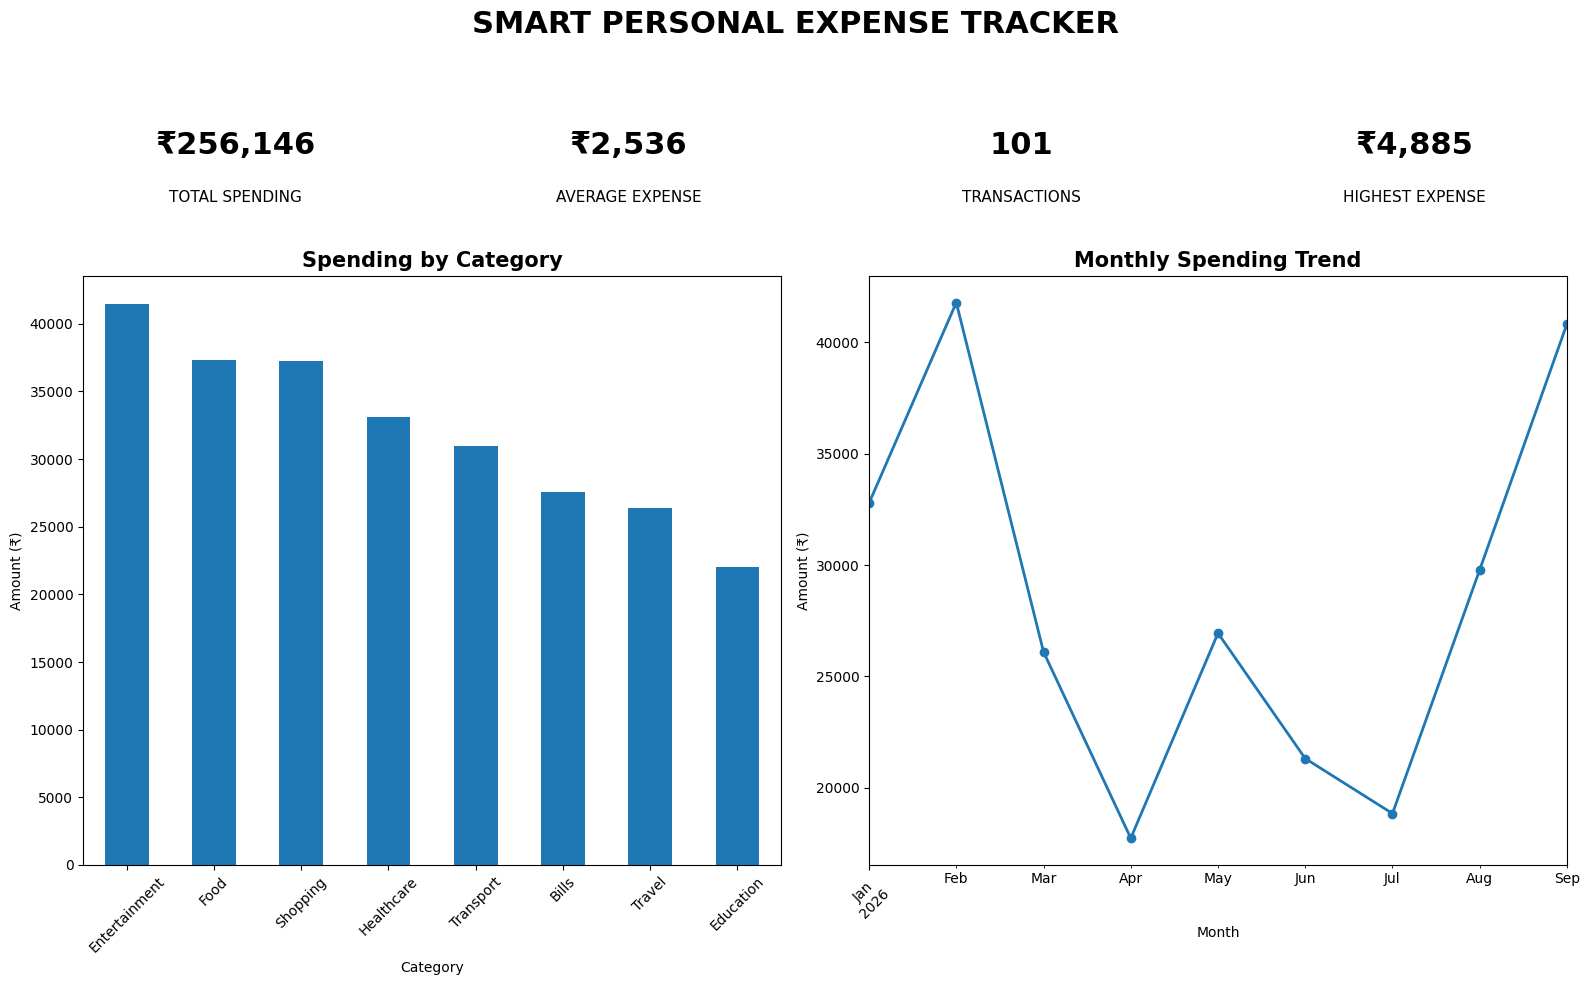


========== KEY DASHBOARD INSIGHTS ==========
💰 Total Spending       : ₹256,146.00
📊 Average Expense      : ₹2,536.10
🧾 Total Transactions   : 101
💸 Highest Expense      : ₹4,885.00
🏆 Top Category         : Entertainment
📅 Highest Spending Month: 2026-02

Dashboard generated successfully! ✅

Dashboard displayed successfully! ✅

Run main_menu() again in a NEW cell to continue.


In [63]:
main_menu()

In [64]:
main_menu()



          SMART PERSONAL EXPENSE TRACKER
             SPENDING ANALYTICS SYSTEM

--------------- EXPENSE MANAGEMENT ---------------
1.  Add Expense
2.  View Expenses
3.  Delete Expense
4.  Search / Filter Expenses

--------------- ANALYSIS & REPORTS ---------------
5.  Expense Report
6.  Category Analysis
7.  Monthly Analysis
8.  Budget Analysis
9.  Smart Spending Insights

--------------- DASHBOARDS & EXPORT -------------
10. Spending Dashboard
11. Budget Dashboard
12. Export Excel Report
13. Data Quality Check

14. Exit

-----------------------------------------------------------------
Enter your choice (1-14): 11

========== BUDGET DASHBOARD ==========

Available Months:
- 2026-01
- 2026-02
- 2026-03
- 2026-04
- 2026-05
- 2026-06
- 2026-07
- 2026-08
- 2026-09

Enter month (YYYY-MM): 12
Invalid month.

Budget Dashboard completed! ✅

Run main_menu() again in a NEW cell to continue.


In [65]:
def final_system_check():

    print("=" * 65)
    print("       SMART PERSONAL EXPENSE TRACKER")
    print("             FINAL SYSTEM CHECK")
    print("=" * 65)

    # 1. Expense data
    print("\n[1] Expense Data")
    print("-" * 45)

    print(f"Transactions : {len(expenses)}")

    if len(expenses) > 0:
        print("Status       : PASS ✅")
    else:
        print("Status       : FAIL ❌")

    # 2. Pandas DataFrame
    print("\n[2] Pandas DataFrame")
    print("-" * 45)

    print(f"Rows         : {len(df)}")
    print(f"Columns      : {len(df.columns)}")

    if len(df) == len(expenses):
        print("Status       : PASS ✅")
    else:
        print("Status       : FAIL ❌")

    # 3. Required columns
    print("\n[3] Required Columns")
    print("-" * 45)

    required_columns = [
        "amount",
        "category",
        "date",
        "description"
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if len(missing_columns) == 0:
        print("All required columns present.")
        print("Status       : PASS ✅")
    else:
        print("Missing columns:", missing_columns)
        print("Status       : FAIL ❌")

    # 4. Amount validation
    print("\n[4] Amount Validation")
    print("-" * 45)

    invalid_amounts = (df["amount"] <= 0).sum()

    print(f"Invalid amounts: {invalid_amounts}")

    if invalid_amounts == 0:
        print("Status       : PASS ✅")
    else:
        print("Status       : FAIL ❌")

    # 5. Date validation
    print("\n[5] Date Validation")
    print("-" * 45)

    invalid_dates = df["date"].isna().sum()

    print(f"Invalid dates: {invalid_dates}")

    if invalid_dates == 0:
        print("Status       : PASS ✅")
    else:
        print("Status       : FAIL ❌")

    # 6. Google Drive
    print("\n[6] Google Drive Storage")
    print("-" * 45)

    csv_exists = os.path.exists(CSV_FILE)

    print(f"CSV file exists: {csv_exists}")

    if csv_exists:
        print("Status       : PASS ✅")
    else:
        print("Status       : FAIL ❌")

    # 7. Excel report
    print("\n[7] Excel Report")
    print("-" * 45)

    excel_file = os.path.join(
        PROJECT_FOLDER,
        "expense_analysis_report.xlsx"
    )

    excel_exists = os.path.exists(excel_file)

    print(f"Excel file exists: {excel_exists}")

    if excel_exists:
        print("Status       : PASS ✅")
    else:
        print("Status       : FAIL ❌")

    # 8. Summary
    print("\n" + "=" * 65)
    print("                 FINAL SUMMARY")
    print("=" * 65)

    total_spending = df["amount"].sum()

    print(f"Total Transactions : {len(df)}")
    print(f"Total Spending     : ₹{total_spending:,.2f}")
    print(f"Categories         : {df['category'].nunique()}")
    print(f"Months             : {df['month'].nunique()}")

    # Overall status
    all_passed = (
        len(expenses) > 0
        and len(df) == len(expenses)
        and len(missing_columns) == 0
        and invalid_amounts == 0
        and invalid_dates == 0
        and csv_exists
        and excel_exists
    )

    print("\n" + "=" * 65)

    if all_passed:
        print("       OVERALL STATUS: PROJECT READY ✅")
    else:
        print("       OVERALL STATUS: NEEDS REVIEW ⚠️")

    print("=" * 65)

In [66]:
final_system_check()

       SMART PERSONAL EXPENSE TRACKER
             FINAL SYSTEM CHECK

[1] Expense Data
---------------------------------------------
Transactions : 104
Status       : PASS ✅

[2] Pandas DataFrame
---------------------------------------------
Rows         : 101
Columns      : 5
Status       : FAIL ❌

[3] Required Columns
---------------------------------------------
All required columns present.
Status       : PASS ✅

[4] Amount Validation
---------------------------------------------
Invalid amounts: 0
Status       : PASS ✅

[5] Date Validation
---------------------------------------------
Invalid dates: 0
Status       : PASS ✅

[6] Google Drive Storage
---------------------------------------------
CSV file exists: True
Status       : PASS ✅

[7] Excel Report
---------------------------------------------
Excel file exists: True
Status       : PASS ✅

                 FINAL SUMMARY
Total Transactions : 101
Total Spending     : ₹256,146.00
Categories         : 8
Months             : 9



In [67]:
refresh_dataframe()

DataFrame synchronized successfully! ✅
Total records: 104


In [68]:
print("Expenses list:", len(expenses))
print("DataFrame rows:", len(df))

if len(expenses) == len(df):
    print("✅ Data is synchronized successfully!")
else:
    print("❌ Data is still not synchronized.")

Expenses list: 104
DataFrame rows: 104
✅ Data is synchronized successfully!


In [69]:
final_system_check()

       SMART PERSONAL EXPENSE TRACKER
             FINAL SYSTEM CHECK

[1] Expense Data
---------------------------------------------
Transactions : 104
Status       : PASS ✅

[2] Pandas DataFrame
---------------------------------------------
Rows         : 104
Columns      : 5
Status       : PASS ✅

[3] Required Columns
---------------------------------------------
All required columns present.
Status       : PASS ✅

[4] Amount Validation
---------------------------------------------
Invalid amounts: 0
Status       : PASS ✅

[5] Date Validation
---------------------------------------------
Invalid dates: 0
Status       : PASS ✅

[6] Google Drive Storage
---------------------------------------------
CSV file exists: True
Status       : PASS ✅

[7] Excel Report
---------------------------------------------
Excel file exists: True
Status       : PASS ✅

                 FINAL SUMMARY
Total Transactions : 104
Total Spending     : ₹256,896.00
Categories         : 9
Months             : 9



# SMART PERSONAL EXPENSE TRACKER & SPENDING ANALYTICS SYSTEM

## Project Overview

This project is a Python-based personal expense management and spending analytics system.

The system allows users to record, view, search, analyze, and manage expenses. It also provides category-wise and monthly spending analysis, budget monitoring, smart spending insights, data-quality validation, visual dashboards, and Excel report generation.

### Technologies Used
- Python
- CSV
- Pandas
- Matplotlib
- Google Drive
- Excel

### Main Features
1. Expense Management
2. Search and Filtering
3. Expense Reports
4. Category Analysis
5. Monthly Analysis
6. Budget Analysis
7. Smart Spending Insights
8. Spending Dashboard
9. Budget Dashboard
10. Data Quality Validation
11. Excel Report Export
12. Google Drive Data Persistence

**Note:** The initial dataset used for analysis contains synthetic/sample transactions created for project demonstration and testing.

## Project Objectives

The main objectives of this project are:

1. To develop a Python-based system for recording and managing personal expenses.

2. To store expense information using CSV file handling and Google Drive persistence.

3. To provide search and filtering options for quickly finding expense records.

4. To analyze spending based on categories and months.

5. To calculate important financial metrics such as total spending, average expense, and highest expense.

6. To provide budget monitoring and identify whether spending is within or above the planned budget.

7. To generate smart spending insights and recommendations based on expense patterns.

8. To visualize spending patterns using charts and dashboards.

9. To validate the quality of expense data by checking missing values, duplicates, invalid amounts, and invalid dates.

10. To generate an Excel-based analysis report for further use and reference.

## Project Modules

The project is divided into the following modules:

### 1. Expense Management Module
Allows users to add, view, and delete expense records.

### 2. Data Storage Module
Stores expense records in CSV format and maintains persistent storage using Google Drive.

### 3. Search and Filter Module
Allows users to search expenses by category, date, and amount range.

### 4. Expense Analysis Module
Calculates total spending, average expense, highest expense, lowest expense, and other financial metrics.

### 5. Category Analysis Module
Analyzes total spending for each expense category and calculates its percentage contribution.

### 6. Monthly Analysis Module
Groups expenses by month and identifies monthly spending patterns.

### 7. Budget Management Module
Compares monthly spending with a user-defined budget and provides budget status and recommendations.

### 8. Smart Insights Module
Generates useful observations and recommendations based on spending patterns.

### 9. Visualization Module
Uses Matplotlib to create category spending charts, monthly trends, pie charts, and box plots.

### 10. Dashboard Module
Provides a consolidated visual summary of important spending information.

### 11. Data Quality Module
Checks the dataset for missing values, duplicate records, invalid amounts, and invalid dates.

### 12. Report Export Module
Generates an Excel report containing summary information, category analysis, monthly analysis, and transaction data.

## Project Methodology

The system follows a structured data-processing workflow:

### Step 1: Expense Input
The user enters the expense amount, category, date, and description through the menu-driven application.

### Step 2: Input Validation
The system validates the entered amount and date to prevent invalid data from being stored.

### Step 3: Data Storage
Valid expense records are stored in a Python list using dictionaries. The data is saved to a CSV file in Google Drive for permanent storage.

### Step 4: Data Loading
When the project starts, previously saved expense records are loaded from Google Drive.

### Step 5: Data Processing
Pandas is used to convert the expense records into a DataFrame for efficient analysis and processing.

### Step 6: Data Cleaning and Validation
The system checks for missing values, duplicate records, invalid amounts, and invalid dates.

### Step 7: Data Analysis
The system performs category-wise, monthly, budget, and overall spending analysis.

### Step 8: Visualization
Matplotlib is used to represent spending patterns through charts and dashboards.

### Step 9: Smart Insights
The system identifies important spending patterns and generates simple recommendations.

### Step 10: Report Generation
The analyzed information can be exported to an Excel report containing summary, category analysis, monthly analysis, and transaction data.

### Overall Workflow

User Input
    ↓
Validation
    ↓
CSV / Google Drive Storage
    ↓
Pandas DataFrame
    ↓
Data Cleaning
    ↓
Data Analysis
    ↓
Visualization & Smart Insights
    ↓
Dashboard
    ↓
Excel Report

## Technologies and Tools Used

### Python
Python is used as the primary programming language for developing the expense tracker, implementing functions, menu control, validation, calculations, and application logic.

### CSV
CSV file handling is used to store and retrieve expense records in a structured format.

### Pandas
Pandas is used for data manipulation, cleaning, grouping, aggregation, and statistical analysis.

### Matplotlib
Matplotlib is used to create visualizations such as bar charts, pie charts, line charts, and box plots.

### Google Drive
Google Drive is used for persistent storage of the project's expense CSV file, allowing the data to remain available across Colab runtime sessions.

### Excel
Excel export is used to generate an analysis report containing summary information, category analysis, monthly analysis, and all transaction records.

### Google Colab
Google Colab is used as the development and execution environment for the Python project.

## Expected Project Outcomes

The completed system is designed to provide the following outcomes:

- Efficient recording and management of personal expenses.
- Reliable storage and retrieval of expense information.
- Easy searching and filtering of transactions.
- Clear understanding of category-wise spending.
- Identification of monthly spending patterns.
- Monitoring of spending against a defined budget.
- Automatic identification of important spending patterns.
- Visual representation of financial data through charts and dashboards.
- Identification of basic data-quality issues.
- Generation of an Excel-based expense analysis report.
- Persistent storage of expense data using Google Drive.

The system demonstrates how Python programming and data-analysis techniques can be combined to develop a practical financial management application.

## Limitations

Although the system provides several useful expense-management and analysis features, it has some limitations:

1. The current application is primarily a menu-driven Python application and does not have a graphical user interface.

2. The system does not connect directly to bank accounts or payment applications.

3. Budget information is currently entered by the user when performing budget analysis.

4. The smart insights are rule-based and do not use machine learning.

5. The analysis is based on the expense records available in the system.

6. The project uses synthetic/sample transactions for demonstration and testing rather than claiming to represent actual personal financial records.

## Future Scope

The project can be enhanced in the future by adding:

1. A web or graphical user interface for easier interaction.

2. User login and authentication.

3. Multiple-user expense management.

4. Automatic synchronization with bank and payment transactions through authorized APIs.

5. Machine-learning-based spending prediction.

6. Personalized recommendations based on historical spending behavior.

7. Automatic monthly budget suggestions.

8. Email or mobile notifications for budget limits.

9. Interactive dashboards using advanced visualization tools.

10. Cloud database integration for scalable data storage.

These enhancements could transform the current Python-based expense tracker into a more advanced personal financial management platform.

## Conclusion

The Smart Personal Expense Tracker & Spending Analytics System successfully demonstrates the use of Python programming and data-analysis techniques to develop a practical expense-management application.

The system provides functionality for recording, viewing, deleting, searching, and analyzing expenses. It uses CSV file handling and Google Drive for persistent data storage, while Pandas is used for structured data processing and analysis.

The project provides category-wise and monthly spending analysis, budget monitoring, smart spending insights, data-quality validation, visual dashboards, and Excel report generation.

The use of Matplotlib allows spending patterns to be presented visually, making the analytical results easier to understand.

Overall, the project demonstrates how Python, data handling, analysis, and visualization can be combined to build a practical and user-friendly personal expense management system.

# FINAL PROJECT SUMMARY

## Smart Personal Expense Tracker & Spending Analytics System

This project combines Python programming, data storage, data processing, statistical analysis, visualization, budgeting, and automated insights into a single expense-management system.

### Key Capabilities

✅ Add and manage expense records  
✅ View and search transactions  
✅ Delete incorrect expense records  
✅ Store data using CSV and Google Drive  
✅ Process data using Pandas  
✅ Perform category-wise analysis  
✅ Perform monthly spending analysis  
✅ Monitor monthly budgets  
✅ Generate smart spending insights  
✅ Perform data-quality validation  
✅ Create spending dashboards  
✅ Create budget dashboards  
✅ Export analytical results to Excel  

### Project Status

**Functional implementation:** Completed ✅

**Data persistence:** Google Drive ✅

**Data analysis:** Pandas ✅

**Visualization:** Matplotlib ✅

**Reporting:** Excel export ✅

**Application testing:** Completed ✅

---

## Final Note

The project is intended as an educational and internship demonstration of Python programming and data analytics. The sample transaction dataset used during development contains synthetic/sample records for demonstration and testing purposes.